# 🏦 HPB Fintech Hackathon 2026 — Exploratory Data Analysis
## AI sustav za predviđanje odlaska klijenata i retencijske mjere

**Goal:** Understand the dataset structure, define customer churn, and identify features that are most predictive of churn behavior.

### Data Model Overview
We have **5 interconnected tables** provided by HPB:

| Table | Description | Records |
|-------|------------|---------|
| **KLIJENTI** (Clients) | Demographics, employment, credit rating, residency | 11,997 |
| **PROIZVODI** (Products) | Products per client — cards, accounts, deposits, loans, channels | 58,703 |
| **STANJA PROIZVODA** (Product Balances) | Time-series of account/product balances | 817,933 |
| **TRANSAKCIJE** (Transactions) | Individual transactions with channel, direction, amounts | 1,048,575 |
| **KONTAKT CENTAR** (Contact Center) | Customer support tickets — queries, complaints, requests | 23,605 |

### Churn Definition
We define **churn** as: a client who has **closed all their products** (every product has a `DATUM_ZATVARANJA` filled in). This represents a client who has completely severed their relationship with the bank.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Style configuration
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

COLORS = {'active': '#2ecc71', 'churned': '#e74c3c'}
PALETTE_CHURN = [COLORS['active'], COLORS['churned']]

DATA = Path('../data')
print("✅ Libraries loaded")

✅ Libraries loaded


---
## 1. Data Loading & Cleaning

We load all 5 tables from pre-processed CSV files. Key cleaning steps:
- Parse European-format dates (`d/m/yyyy/`) 
- Convert decimal commas to dots for numeric fields
- Create the **churn label** based on product closure status

In [2]:
# ── Helper: parse European dates (d/m/yyyy/) ──
def parse_eu_date(s):
    """Parse dates like '1/3/2007/' or '13/8/2007/' to datetime."""
    return pd.to_datetime(s.str.strip().str.rstrip('/'), format='%d/%m/%Y', errors='coerce')

def parse_eu_datetime(s):
    """Parse datetimes like '8/5/2025/ 14:06:05'."""
    return pd.to_datetime(s.str.strip().str.replace('/ ', ' ', regex=False), format='%d/%m/%Y %H:%M:%S', errors='coerce')

def eu_to_float(s):
    """Convert European decimal strings ('430,04') to float."""
    return pd.to_numeric(s.str.replace('.', '', regex=False).str.replace(',', '.', regex=False), errors='coerce')

# ── 1. KLIJENTI (Clients) ──
klijenti = pd.read_csv(DATA / 'klijenti.csv', dtype=str)
klijenti['DOB'] = pd.to_numeric(klijenti['DOB'], errors='coerce')
klijenti['DATUM_PRVOG_POCETKA_POSLOVNOG_ODNOSA'] = parse_eu_date(klijenti['DATUM_PRVOG_POCETKA_POSLOVNOG_ODNOSA'])
klijenti['DATUM_ZADNJEG_POCETKA_POSLOVNOG_ODNOSA'] = parse_eu_date(klijenti['DATUM_ZADNJEG_POCETKA_POSLOVNOG_ODNOSA'])
for col in ['GODINE_STAZA_KOD_TRENUTNOG_POSLODAVCA', 'GODINE_STAZA',
            'BROJ_CLANOVA_KUCANSTVA', 'BROJ_UZDRZAVANIH_CLANOVA_KUCANSTVA']:
    klijenti[col] = pd.to_numeric(klijenti[col], errors='coerce')
klijenti['TENURE_YEARS'] = (pd.Timestamp('2026-04-01') - klijenti['DATUM_PRVOG_POCETKA_POSLOVNOG_ODNOSA']).dt.days / 365.25
print(f"✅ Klijenti: {klijenti.shape}")

# ── 2. PROIZVODI (Products) ──
proizvodi = pd.read_csv(DATA / 'proizvodi.csv', dtype=str)
proizvodi['DATUM_OTVARANJA'] = parse_eu_date(proizvodi['DATUM_OTVARANJA'])
proizvodi['DATUM_ZATVARANJA'] = parse_eu_date(proizvodi['DATUM_ZATVARANJA'])
proizvodi['IS_CLOSED'] = proizvodi['DATUM_ZATVARANJA'].notna()
print(f"✅ Proizvodi: {proizvodi.shape}")

# ── 3. STANJA PROIZVODA (Product Balances) ──
stanja = pd.read_csv(DATA / 'stanja.csv', dtype=str)
stanja['STANJE_U_VALUTI'] = eu_to_float(stanja['STANJE_U_VALUTI'])
stanja['STANJE_U_DOMICILNOJ_VALUTI'] = eu_to_float(stanja['STANJE_U_DOMICILNOJ_VALUTI'])
stanja['VRIJEDI_OD'] = parse_eu_date(stanja['VRIJEDI_OD'])
stanja['VRIJEDI_DO'] = parse_eu_date(stanja['VRIJEDI_DO'])
print(f"✅ Stanja: {stanja.shape}")

# ── 4. TRANSAKCIJE (Transactions) ──
transakcije = pd.read_csv(DATA / 'transakcije.csv', dtype=str)
# Drop trailing empty column if present
transakcije = transakcije.loc[:, transakcije.columns.notna()]
transakcije['DATUM_I_VRIJEME_TRANSAKCIJE'] = parse_eu_datetime(transakcije['DATUM_I_VRIJEME_TRANSAKCIJE'])
transakcije['IZNOS_TRANSAKCIJE_U_DOMICILNOJ_VALUTI'] = eu_to_float(transakcije['IZNOS_TRANSAKCIJE_U_DOMICILNOJ_VALUTI'])
transakcije['MONTH'] = transakcije['DATUM_I_VRIJEME_TRANSAKCIJE'].dt.to_period('M')
print(f"✅ Transakcije: {transakcije.shape}")

# ── 5. KONTAKT CENTAR (Contact Center) ──
kontakt = pd.read_csv(DATA / 'kontakt.csv', dtype=str)
kontakt['VRIJEME_KREIRANJA'] = parse_eu_datetime(kontakt['VRIJEME_KREIRANJA'])
kontakt['VRIJEME_ZADNJE_IZMJENE'] = parse_eu_datetime(kontakt['VRIJEME_ZADNJE_IZMJENE'])
print(f"✅ Kontakt: {kontakt.shape}")

# ── Create CHURN label ──
# Client is "churned" if ALL their products are closed
prod_status = proizvodi.groupby('IDENTIFIKATOR_KLIJENTA').agg(
    total_products=('IS_CLOSED', 'size'),
    closed_products=('IS_CLOSED', 'sum')
).reset_index()
prod_status['CHURNED'] = (prod_status['total_products'] == prod_status['closed_products']).astype(int)

# Merge churn label onto klijenti
klijenti = klijenti.merge(prod_status[['IDENTIFIKATOR_KLIJENTA', 'total_products', 'closed_products', 'CHURNED']],
                          on='IDENTIFIKATOR_KLIJENTA', how='left')
# Clients without any products — mark as churned (no relationship)
klijenti['CHURNED'] = klijenti['CHURNED'].fillna(1).astype(int)
klijenti['CHURN_LABEL'] = klijenti['CHURNED'].map({0: 'Active', 1: 'Churned'})

print(f"\n{'='*50}")
print(f"CHURN DISTRIBUTION:")
print(f"  Active:  {(klijenti['CHURNED']==0).sum():,} ({(klijenti['CHURNED']==0).mean():.1%})")
print(f"  Churned: {(klijenti['CHURNED']==1).sum():,} ({(klijenti['CHURNED']==1).mean():.1%})")
print(f"{'='*50}")

✅ Klijenti: (11997, 39)
✅ Proizvodi: (58703, 14)
✅ Stanja: (817933, 6)
✅ Transakcije: (1048575, 12)
✅ Kontakt: (23605, 5)

CHURN DISTRIBUTION:
  Active:  2,975 (24.8%)
  Churned: 9,022 (75.2%)


### Key Observation — Churn Rate
The overall churn rate is **75.2%** (9,022 out of 11,997 clients). This is extremely high and reflects the nature of the synthetic dataset which covers a very long historical period (some relationships going back to the 1990s). Many of these are clients who had products at some point but have since closed them all.

This high base rate is important context: the bank has a large pool of historical churners to learn patterns from, but any predictive model must be calibrated carefully to avoid simply predicting "everyone churns."

---
## 2. Dataset Overview & Missing Values

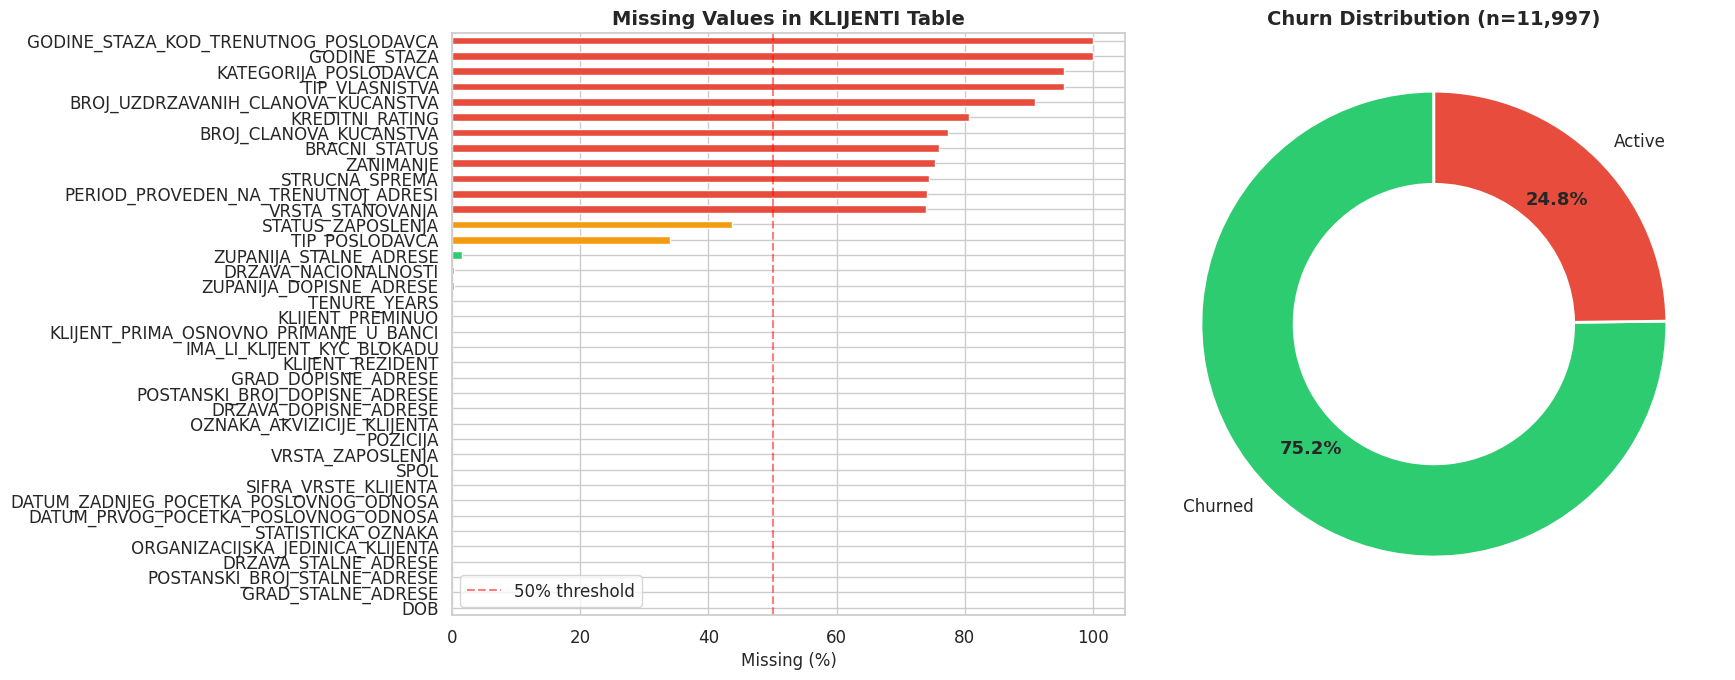


📊 KLIJENTI — Key statistics:
   Total clients:     11,997
   Columns:           43
   Avg products/client: 5.7
   Median age (DOB):  59 years
   Avg tenure:        15.3 years


In [3]:
# ── Missing values heatmap for Klijenti ──
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: Missing values percentage
missing_pct = (klijenti.drop(columns=['IDENTIFIKATOR_KLIJENTA','CHURNED','CHURN_LABEL','total_products','closed_products'])
               .isnull().mean().sort_values(ascending=True) * 100)
colors = ['#e74c3c' if x > 50 else '#f39c12' if x > 20 else '#2ecc71' for x in missing_pct.values]
missing_pct.plot(kind='barh', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_xlabel('Missing (%)')
axes[0].set_title('Missing Values in KLIJENTI Table', fontweight='bold')
axes[0].axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
axes[0].legend()

# Right: Churn distribution donut chart
churn_counts = klijenti['CHURN_LABEL'].value_counts()
wedges, texts, autotexts = axes[1].pie(
    churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
    colors=PALETTE_CHURN, startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2))
for t in autotexts:
    t.set_fontsize(13)
    t.set_fontweight('bold')
axes[1].set_title(f'Churn Distribution (n={len(klijenti):,})', fontweight='bold')

plt.tight_layout()
plt.show()

# Summary statistics
print(f"\n📊 KLIJENTI — Key statistics:")
print(f"   Total clients:     {len(klijenti):,}")
print(f"   Columns:           {klijenti.shape[1]}")
print(f"   Avg products/client: {klijenti['total_products'].mean():.1f}")
print(f"   Median age (DOB):  {klijenti['DOB'].median():.0f} years")
print(f"   Avg tenure:        {klijenti['TENURE_YEARS'].mean():.1f} years")

### Observations — Dataset Quality
- **Many demographic fields have 50-95% missing values** — employment tenure, employer category, housing type, marital status, education. These are optional fields in the bank's CRM and are filled only for a subset of clients.
- **Core fields are complete**: age (DOB), gender (SPOL), dates, addresses, and key flags like `KLIJENT_PREMINUO` and `KLIJENT_PRIMA_OSNOVNO_PRIMANJE_U_BANCI`.
- The median client is **59 years old** with **15+ years of relationship** — indicating a mature, long-standing customer base.
- Each client has on average **5.7 products** — showing significant product penetration.

---
## 3. Client Demographics vs. Churn

Let's explore how demographic features relate to churn behavior.

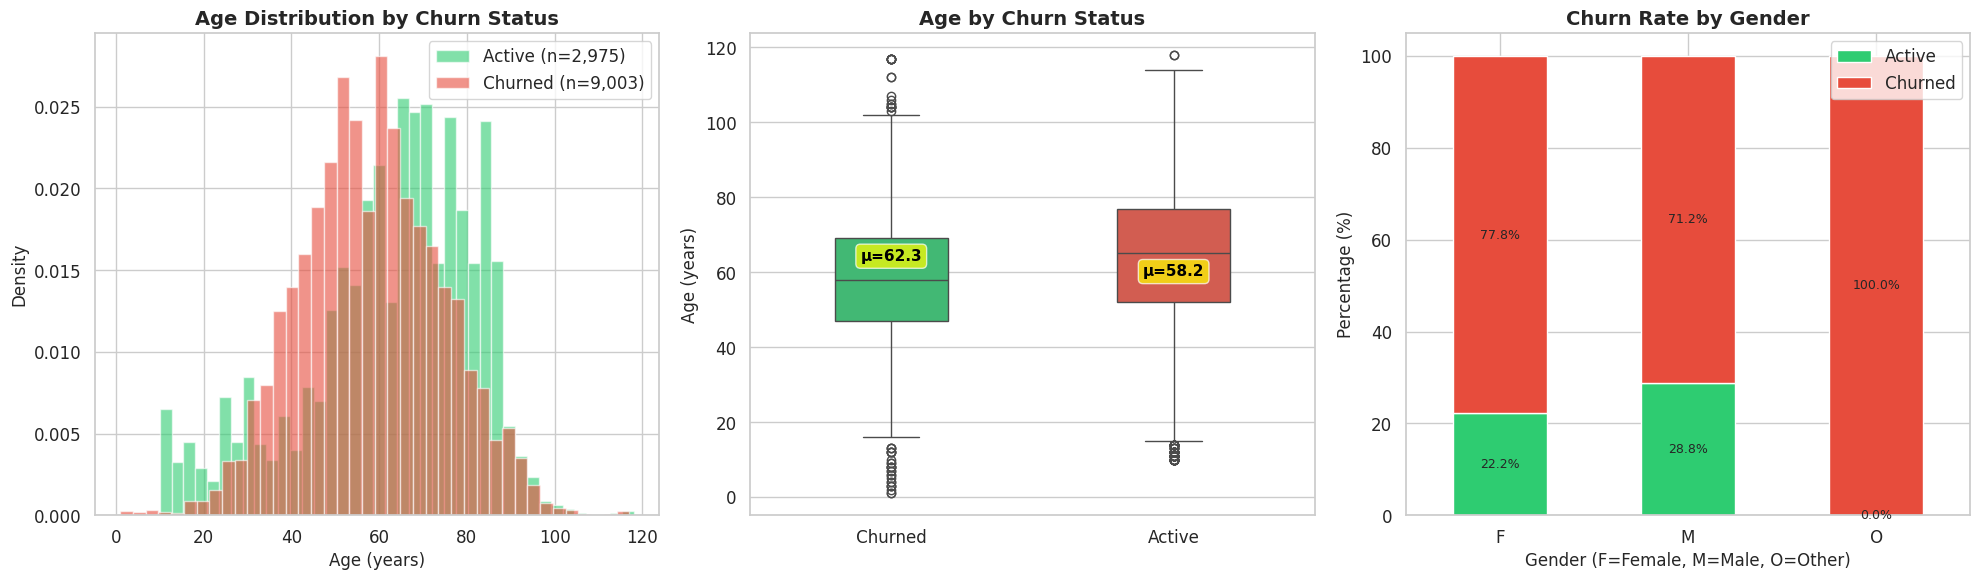

📊 Age statistics by churn:
             mean   50%   std
CHURN_LABEL                  
Active       62.3  65.0  19.6
Churned      58.2  58.0  16.0


In [4]:
# ── 3.1 Age Distribution by Churn ──
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Filter out extreme ages
age_valid = klijenti[(klijenti['DOB'] > 0) & (klijenti['DOB'] < 120)].copy()

# Age distribution
for label, color in zip(['Active', 'Churned'], PALETTE_CHURN):
    subset = age_valid[age_valid['CHURN_LABEL'] == label]
    axes[0].hist(subset['DOB'], bins=40, alpha=0.6, label=f'{label} (n={len(subset):,})',
                 color=color, edgecolor='white', density=True)
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Density')
axes[0].set_title('Age Distribution by Churn Status', fontweight='bold')
axes[0].legend()

# Age boxplot
sns.boxplot(data=age_valid, x='CHURN_LABEL', y='DOB', palette=PALETTE_CHURN, ax=axes[1], width=0.4)
axes[1].set_xlabel('')
axes[1].set_ylabel('Age (years)')
axes[1].set_title('Age by Churn Status', fontweight='bold')
# Add means
for i, label in enumerate(['Active', 'Churned']):
    mean_val = age_valid[age_valid['CHURN_LABEL'] == label]['DOB'].mean()
    axes[1].annotate(f'μ={mean_val:.1f}', xy=(i, mean_val), fontsize=11, fontweight='bold',
                     ha='center', va='bottom', color='black',
                     bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

# Gender vs Churn
gender_churn = klijenti.groupby(['SPOL', 'CHURN_LABEL']).size().unstack(fill_value=0)
gender_churn_pct = gender_churn.div(gender_churn.sum(axis=1), axis=0) * 100
gender_churn_pct[['Active', 'Churned']].plot(kind='bar', stacked=True, ax=axes[2],
                                              color=PALETTE_CHURN, edgecolor='white')
axes[2].set_xlabel('Gender (F=Female, M=Male, O=Other)')
axes[2].set_ylabel('Percentage (%)')
axes[2].set_title('Churn Rate by Gender', fontweight='bold')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)
axes[2].legend(loc='upper right')
for container in axes[2].containers:
    axes[2].bar_label(container, fmt='%.1f%%', label_type='center', fontsize=9)

plt.tight_layout()
plt.show()

# Print statistics
print("📊 Age statistics by churn:")
print(age_valid.groupby('CHURN_LABEL')['DOB'].describe()[['mean', '50%', 'std']].round(1))

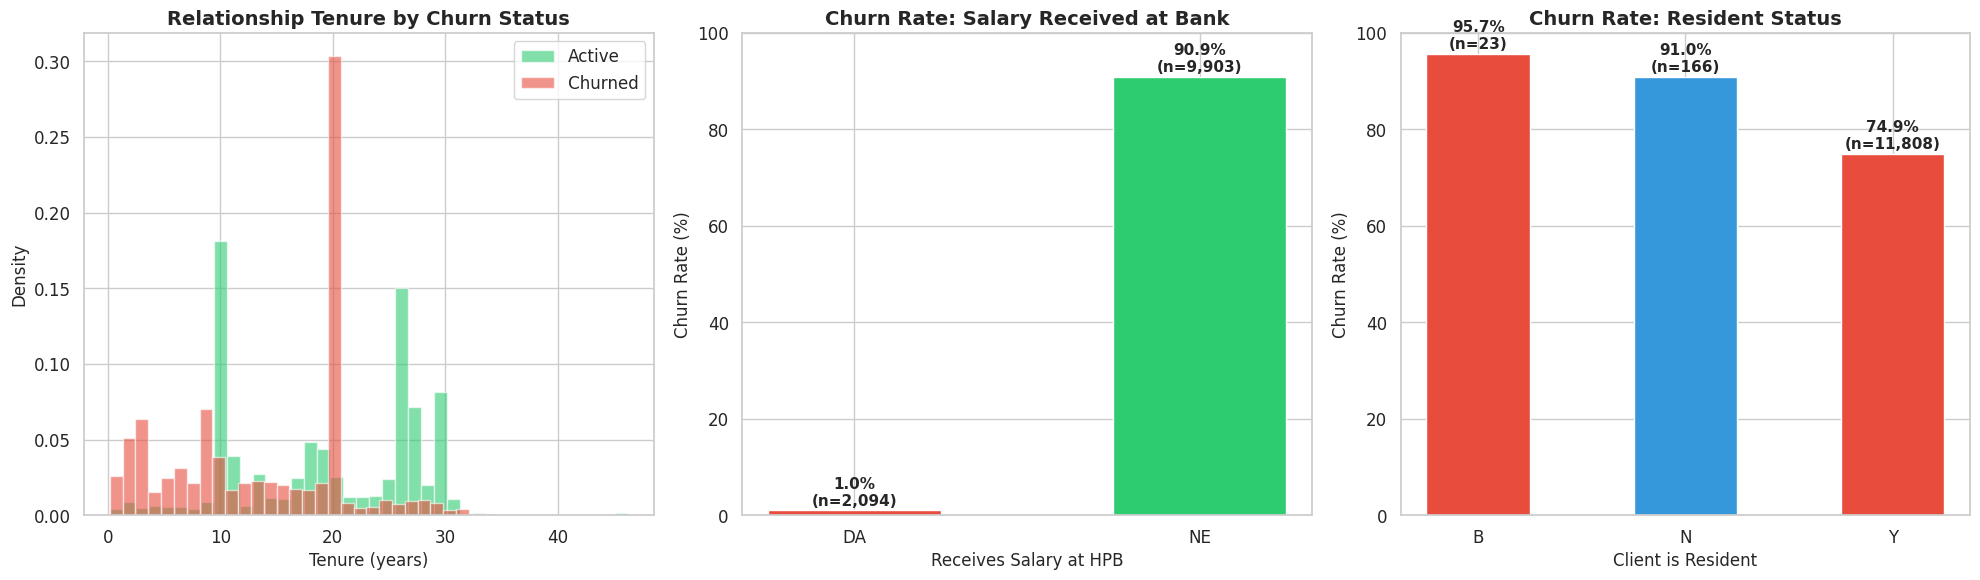

In [5]:
# ── 3.2 Tenure & Key Flags vs Churn ──
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Tenure distribution
tenure_valid = klijenti[klijenti['TENURE_YEARS'].notna() & (klijenti['TENURE_YEARS'] > 0)]
for label, color in zip(['Active', 'Churned'], PALETTE_CHURN):
    subset = tenure_valid[tenure_valid['CHURN_LABEL'] == label]
    axes[0].hist(subset['TENURE_YEARS'], bins=40, alpha=0.6, label=f'{label}',
                 color=color, edgecolor='white', density=True)
axes[0].set_xlabel('Tenure (years)')
axes[0].set_ylabel('Density')
axes[0].set_title('Relationship Tenure by Churn Status', fontweight='bold')
axes[0].legend()

# Key binary flags vs churn
flags = ['KLIJENT_PRIMA_OSNOVNO_PRIMANJE_U_BANCI', 'KLIJENT_PREMINUO', 'IMA_LI_KLIJENT_KYC_BLOKADU']
flag_labels = ['Receives Salary\nat Bank', 'Client\nDeceased', 'Has KYC\nBlock']
churn_rates = []
for flag in flags:
    for val in klijenti[flag].dropna().unique():
        subset = klijenti[klijenti[flag] == val]
        rate = subset['CHURNED'].mean() * 100
        churn_rates.append({'flag': flag, 'value': val, 'churn_rate': rate, 'count': len(subset)})

flag_df = pd.DataFrame(churn_rates)

# Salary at bank
sal = klijenti.groupby('KLIJENT_PRIMA_OSNOVNO_PRIMANJE_U_BANCI')['CHURNED'].agg(['mean', 'size']).reset_index()
sal.columns = ['receives_salary', 'churn_rate', 'count']
bars = axes[1].bar(sal['receives_salary'], sal['churn_rate'] * 100, 
                   color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.5)
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xlabel('Receives Salary at HPB')
axes[1].set_title('Churn Rate: Salary Received at Bank', fontweight='bold')
for bar, (_, row) in zip(bars, sal.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{row["churn_rate"]*100:.1f}%\n(n={row["count"]:,})',
                ha='center', fontweight='bold', fontsize=11)
axes[1].set_ylim(0, 100)

# Resident status
res = klijenti.groupby('KLIJENT_REZIDENT')['CHURNED'].agg(['mean', 'size']).reset_index()
res.columns = ['resident', 'churn_rate', 'count']
bars = axes[2].bar(res['resident'], res['churn_rate'] * 100,
                   color=['#e74c3c', '#3498db'], edgecolor='white', width=0.5)
axes[2].set_ylabel('Churn Rate (%)')
axes[2].set_xlabel('Client is Resident')
axes[2].set_title('Churn Rate: Resident Status', fontweight='bold')
for bar, (_, row) in zip(bars, res.iterrows()):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{row["churn_rate"]*100:.1f}%\n(n={row["count"]:,})',
                ha='center', fontweight='bold', fontsize=11)
axes[2].set_ylim(0, 100)

plt.tight_layout()
plt.show()

### Key Findings — Demographics & Churn

1. **Age**: Active clients are slightly older (median 65 vs 58). Active clients show a peak around 60-80 years, while churned clients are more evenly distributed. Older, established clients tend to stay.

2. **Gender**: Female clients have a slightly lower churn rate (77.8%) vs males (71.2%). The "O" (Other) group is tiny (n=40) and fully churned.

3. **🔑 Salary at Bank is the #1 predictor**: Clients who receive their salary at HPB (`DA`) have a **1.0% churn rate** vs **90.9%** for those who don't. This is an extraordinarily strong signal — a client who trusts the bank with their primary income stream is essentially locked in.

4. **Tenure**: Active clients cluster around 15-30 years of relationship. Churned clients show a large spike at ~19 years, suggesting a cohort effect (possibly clients who joined around 2007 and have since left).

5. **Residency**: Non-residents (N, B) have very high churn rates (91-96%), while residents (Y) churn at 74.9%.

---
## 4. Product Portfolio Analysis

Product diversity is a key retention lever. Clients using more products are harder to replace and more likely to stay.

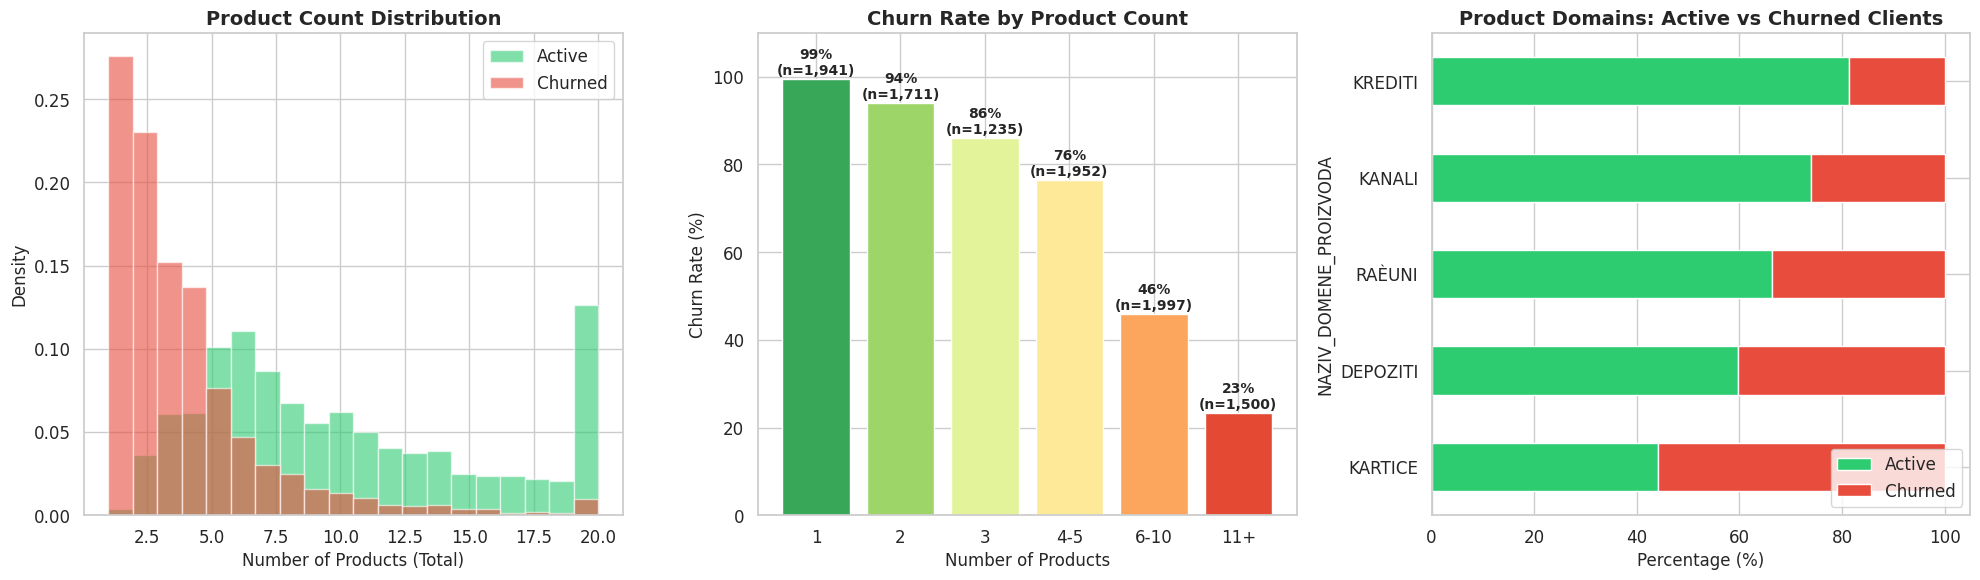


📊 Active clients have on avg 10.6 products
   Churned clients had on avg 3.7 products


In [6]:
# ── 4.1 Product Count vs Churn ──
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Products per client by churn
prod_per_client = proizvodi.groupby('IDENTIFIKATOR_KLIJENTA').agg(
    n_products=('IDENTIFIKATOR_PROIZVODA', 'nunique'),
    n_open=('IS_CLOSED', lambda x: (~x).sum()),
    n_closed=('IS_CLOSED', 'sum')
).reset_index()
prod_per_client = prod_per_client.merge(
    klijenti[['IDENTIFIKATOR_KLIJENTA', 'CHURN_LABEL', 'CHURNED']], on='IDENTIFIKATOR_KLIJENTA')

# Histogram of total products
for label, color in zip(['Active', 'Churned'], PALETTE_CHURN):
    subset = prod_per_client[prod_per_client['CHURN_LABEL'] == label]
    axes[0].hist(subset['n_products'].clip(upper=20), bins=20, alpha=0.6,
                 label=f'{label}', color=color, edgecolor='white', density=True)
axes[0].set_xlabel('Number of Products (Total)')
axes[0].set_ylabel('Density')
axes[0].set_title('Product Count Distribution', fontweight='bold')
axes[0].legend()

# Churn rate by product count buckets
prod_per_client['prod_bucket'] = pd.cut(prod_per_client['n_products'], 
                                         bins=[0, 1, 2, 3, 5, 10, 60],
                                         labels=['1', '2', '3', '4-5', '6-10', '11+'])
bucket_churn = prod_per_client.groupby('prod_bucket').agg(
    churn_rate=('CHURNED', 'mean'),
    count=('CHURNED', 'size')
).reset_index()
bars = axes[1].bar(bucket_churn['prod_bucket'].astype(str), bucket_churn['churn_rate'] * 100,
                   color=sns.color_palette('RdYlGn_r', len(bucket_churn)), edgecolor='white')
axes[1].set_xlabel('Number of Products')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_title('Churn Rate by Product Count', fontweight='bold')
for bar, (_, row) in zip(bars, bucket_churn.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{row["churn_rate"]*100:.0f}%\n(n={row["count"]:,})',
                ha='center', fontsize=10, fontweight='bold')
axes[1].set_ylim(0, 110)

# Product domain distribution by churn
domain_churn = proizvodi.merge(klijenti[['IDENTIFIKATOR_KLIJENTA', 'CHURN_LABEL']], on='IDENTIFIKATOR_KLIJENTA')
domain_counts = domain_churn.groupby(['NAZIV_DOMENE_PROIZVODA', 'CHURN_LABEL']).size().unstack(fill_value=0)
domain_pct = domain_counts.div(domain_counts.sum(axis=1), axis=0) * 100
domain_pct = domain_pct.sort_values('Active', ascending=True)
domain_pct[['Active', 'Churned']].plot(kind='barh', stacked=True, ax=axes[2],
                                        color=PALETTE_CHURN, edgecolor='white')
axes[2].set_xlabel('Percentage (%)')
axes[2].set_title('Product Domains: Active vs Churned Clients', fontweight='bold')
axes[2].legend(loc='lower right')

plt.tight_layout()
plt.show()

print(f"\n📊 Active clients have on avg {prod_per_client[prod_per_client['CHURNED']==0]['n_products'].mean():.1f} products")
print(f"   Churned clients had on avg {prod_per_client[prod_per_client['CHURNED']==1]['n_products'].mean():.1f} products")

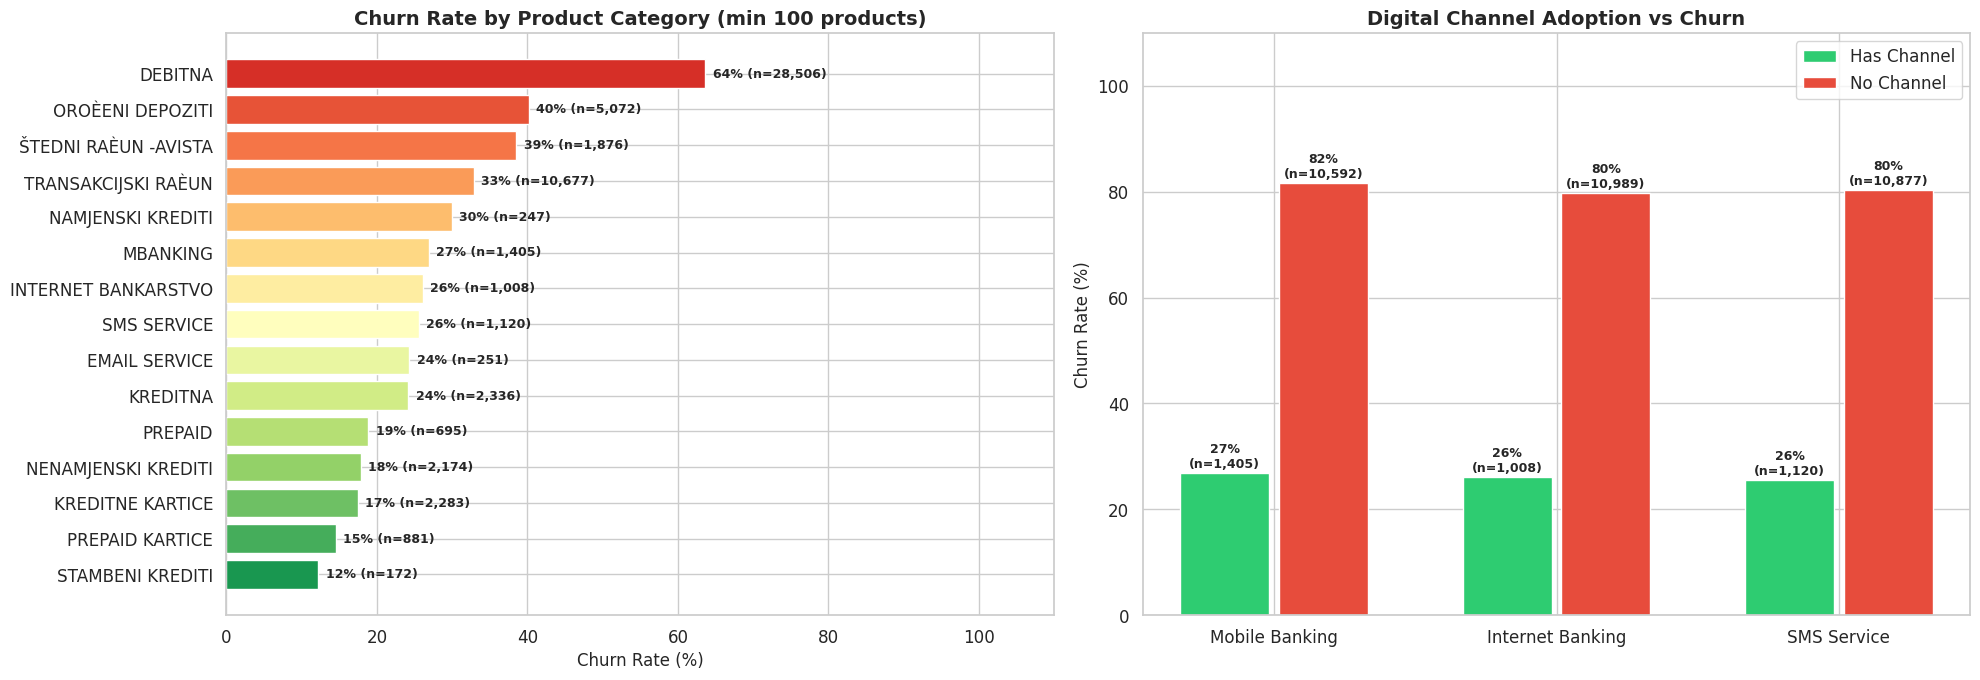

In [7]:
# ── 4.2 Product Categories & Churn Rate by Product Type ──
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Churn rate by product category (top 10)
cat_churn = domain_churn.groupby('NAZIV_KATEGORIJE_PROIZVODA').agg(
    total=('CHURN_LABEL', 'size'),
    active=('CHURN_LABEL', lambda x: (x == 'Active').sum())
).reset_index()
cat_churn['churn_rate'] = 1 - cat_churn['active'] / cat_churn['total']
cat_churn = cat_churn[cat_churn['total'] >= 100].sort_values('churn_rate')

colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(cat_churn)))
bars = axes[0].barh(cat_churn['NAZIV_KATEGORIJE_PROIZVODA'], cat_churn['churn_rate'] * 100,
                    color=colors, edgecolor='white')
axes[0].set_xlabel('Churn Rate (%)')
axes[0].set_title('Churn Rate by Product Category (min 100 products)', fontweight='bold')
for bar, (_, row) in zip(bars, cat_churn.iterrows()):
    axes[0].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f'{row["churn_rate"]*100:.0f}% (n={row["total"]:,})',
                va='center', fontsize=9, fontweight='bold')
axes[0].set_xlim(0, 110)

# Digital channel adoption vs churn
has_digital = proizvodi[proizvodi['NAZIV_DOMENE_PROIZVODA'] == 'KANALI'].groupby('IDENTIFIKATOR_KLIJENTA').size().reset_index()
has_digital.columns = ['IDENTIFIKATOR_KLIJENTA', 'n_digital']
has_digital['has_mbanking'] = proizvodi[proizvodi['NAZIV_KATEGORIJE_PROIZVODA'] == 'MBANKING'].groupby('IDENTIFIKATOR_KLIJENTA').size().reset_index().set_index('IDENTIFIKATOR_KLIJENTA').reindex(has_digital['IDENTIFIKATOR_KLIJENTA']).fillna(0).values
has_digital['has_inet'] = proizvodi[proizvodi['NAZIV_KATEGORIJE_PROIZVODA'] == 'INTERNET BANKARSTVO'].groupby('IDENTIFIKATOR_KLIJENTA').size().reset_index().set_index('IDENTIFIKATOR_KLIJENTA').reindex(has_digital['IDENTIFIKATOR_KLIJENTA']).fillna(0).values

# Merge with churn
digital_churn = has_digital.merge(klijenti[['IDENTIFIKATOR_KLIJENTA', 'CHURNED', 'CHURN_LABEL']], on='IDENTIFIKATOR_KLIJENTA')

# For all clients: who has digital channels?
all_clients = klijenti[['IDENTIFIKATOR_KLIJENTA', 'CHURNED']].copy()
for cat_name, col_name in [('MBANKING', 'has_mbanking'), ('INTERNET BANKARSTVO', 'has_inet'), ('SMS SERVICE', 'has_sms')]:
    cat_clients = set(proizvodi[proizvodi['NAZIV_KATEGORIJE_PROIZVODA'] == cat_name]['IDENTIFIKATOR_KLIJENTA'])
    all_clients[col_name] = all_clients['IDENTIFIKATOR_KLIJENTA'].isin(cat_clients).astype(int)

digital_features = ['has_mbanking', 'has_inet', 'has_sms']
digital_labels = ['Mobile Banking', 'Internet Banking', 'SMS Service']
x = np.arange(len(digital_features))
width = 0.35
for i, (feat, lbl) in enumerate(zip(digital_features, digital_labels)):
    for j, (val, val_label) in enumerate([(1, 'Has'), (0, 'No')]):
        subset = all_clients[all_clients[feat] == val]
        rate = subset['CHURNED'].mean() * 100
        count = len(subset)
        bar = axes[1].bar(i + (j - 0.5) * width, rate, width * 0.9,
                         color=PALETTE_CHURN[j], edgecolor='white',
                         label=val_label if i == 0 else '')
        axes[1].text(i + (j - 0.5) * width, rate + 1, f'{rate:.0f}%\n(n={count:,})',
                    ha='center', fontsize=9, fontweight='bold')

axes[1].set_xticks(x)
axes[1].set_xticklabels(digital_labels)
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_title('Digital Channel Adoption vs Churn', fontweight='bold')
axes[1].legend(['Has Channel', 'No Channel'])
axes[1].set_ylim(0, 110)

plt.tight_layout()
plt.show()

### Key Findings — Product Portfolio & Churn

1. **🔑 Product count is a major churn predictor**: Clients with just 1 product churn at **99%**, while those with 11+ products churn at only **23%**. Active clients average **10.6 products** vs **3.7 for churned** — confirming the banking principle that product cross-sell dramatically reduces attrition.

2. **Product type matters**:
   - **Lowest churn**: Stambeni krediti (mortgages, 12%), Prepaid kartice (15%), Kreditne kartice (17%), Nenamjenski krediti (18%) — credit products create strong lock-in effects
   - **Highest churn**: Debitna (debit cards, 64%), Oročeni depoziti (term deposits, 40%) — basic/passive products
   
3. **🔑 Digital channel adoption is strongly protective**: Clients with Mobile Banking, Internet Banking, or SMS Service have churn rates of **26-27%** vs **80-82%** for those without. Digital engagement creates stickiness and habit formation.

4. **Cards dominate the product portfolio** (34,701 products), with Accounts (12,553) and Deposits (5,072) following. Active clients are proportionally more represented in Kartice and Kanali.

---
## 5. Transaction Behavior Analysis

Transaction patterns reveal engagement levels and behavioral shifts that may signal impending churn.

In [8]:
# ── 5.1 Map transactions to clients via products ──
# Join transakcije -> proizvodi -> klijenti to get churn label
txn_prod = transakcije.merge(
    proizvodi[['IDENTIFIKATOR_PROIZVODA', 'IDENTIFIKATOR_KLIJENTA']],
    on='IDENTIFIKATOR_PROIZVODA', how='left'
)
txn_client = txn_prod.merge(
    klijenti[['IDENTIFIKATOR_KLIJENTA', 'CHURNED', 'CHURN_LABEL']],
    on='IDENTIFIKATOR_KLIJENTA', how='left'
)
txn_client = txn_client.dropna(subset=['CHURNED'])
print(f"Transactions mapped to clients: {len(txn_client):,} / {len(transakcije):,}")

# ── Aggregate transaction features per client ──
txn_agg = txn_client.groupby(['IDENTIFIKATOR_KLIJENTA', 'CHURNED', 'CHURN_LABEL']).agg(
    n_transactions=('IZNOS_TRANSAKCIJE_U_DOMICILNOJ_VALUTI', 'size'),
    total_amount=('IZNOS_TRANSAKCIJE_U_DOMICILNOJ_VALUTI', 'sum'),
    avg_amount=('IZNOS_TRANSAKCIJE_U_DOMICILNOJ_VALUTI', 'mean'),
    n_debit=('SMJER', lambda x: (x == 'D').sum()),
    n_credit=('SMJER', lambda x: (x == 'C').sum()),
    n_channels=('KANAL', 'nunique'),
    first_txn=('DATUM_I_VRIJEME_TRANSAKCIJE', 'min'),
    last_txn=('DATUM_I_VRIJEME_TRANSAKCIJE', 'max'),
).reset_index()
txn_agg['txn_span_days'] = (txn_agg['last_txn'] - txn_agg['first_txn']).dt.days
txn_agg['avg_txn_per_month'] = txn_agg['n_transactions'] / (txn_agg['txn_span_days'].clip(lower=1) / 30)
print(f"Clients with transactions: {len(txn_agg):,}")

Transactions mapped to clients: 1,048,575 / 1,048,575
Clients with transactions: 6,723


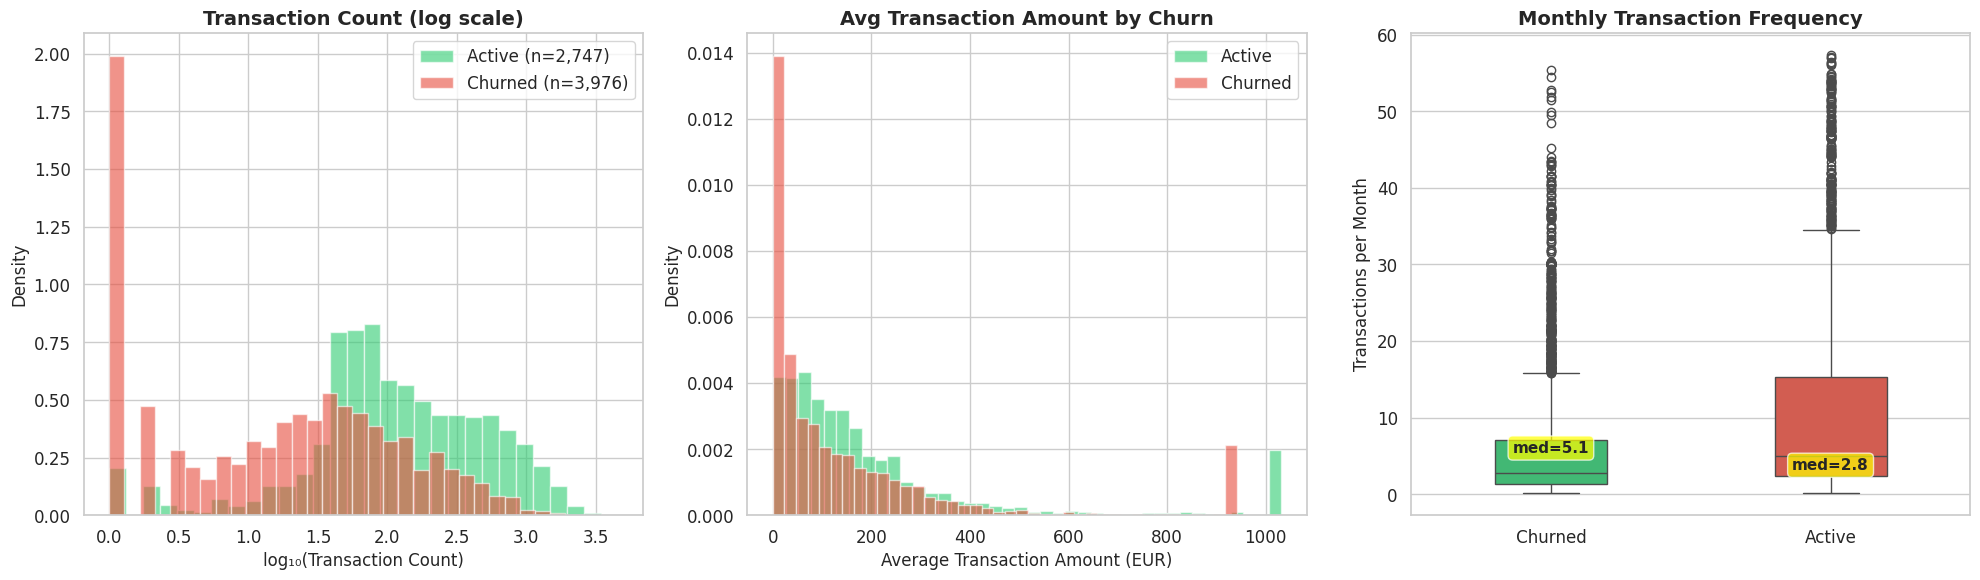

📊 Transaction statistics by churn status:
  Active: median 105 txns, median amount €19,328, median 5.4 txns/month
  Churned: median 20 txns, median amount €2,585, median 3.1 txns/month


In [9]:
# ── 5.2 Transaction Volume & Amount by Churn ──
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Transaction count distribution
for label, color in zip(['Active', 'Churned'], PALETTE_CHURN):
    subset = txn_agg[txn_agg['CHURN_LABEL'] == label]
    axes[0].hist(np.log10(subset['n_transactions'].clip(lower=1)), bins=30, alpha=0.6,
                 label=f'{label} (n={len(subset):,})', color=color, edgecolor='white', density=True)
axes[0].set_xlabel('log₁₀(Transaction Count)')
axes[0].set_ylabel('Density')
axes[0].set_title('Transaction Count (log scale)', fontweight='bold')
axes[0].legend()

# Average transaction amount
for label, color in zip(['Active', 'Churned'], PALETTE_CHURN):
    subset = txn_agg[txn_agg['CHURN_LABEL'] == label]
    vals = subset['avg_amount'].clip(upper=subset['avg_amount'].quantile(0.95))
    axes[1].hist(vals, bins=40, alpha=0.6, label=f'{label}', color=color, edgecolor='white', density=True)
axes[1].set_xlabel('Average Transaction Amount (EUR)')
axes[1].set_ylabel('Density')
axes[1].set_title('Avg Transaction Amount by Churn', fontweight='bold')
axes[1].legend()

# Monthly transaction frequency boxplot
txn_agg_plot = txn_agg[txn_agg['avg_txn_per_month'] < txn_agg['avg_txn_per_month'].quantile(0.95)]
sns.boxplot(data=txn_agg_plot, x='CHURN_LABEL', y='avg_txn_per_month', palette=PALETTE_CHURN, ax=axes[2], width=0.4)
axes[2].set_xlabel('')
axes[2].set_ylabel('Transactions per Month')
axes[2].set_title('Monthly Transaction Frequency', fontweight='bold')
for i, label in enumerate(['Active', 'Churned']):
    mean_val = txn_agg_plot[txn_agg_plot['CHURN_LABEL'] == label]['avg_txn_per_month'].median()
    axes[2].annotate(f'med={mean_val:.1f}', xy=(i, mean_val), fontsize=11, fontweight='bold',
                     ha='center', va='bottom',
                     bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()

# Stats
print("📊 Transaction statistics by churn status:")
for label in ['Active', 'Churned']:
    s = txn_agg[txn_agg['CHURN_LABEL'] == label]
    print(f"  {label}: median {s['n_transactions'].median():.0f} txns, "
          f"median amount €{s['total_amount'].median():,.0f}, "
          f"median {s['avg_txn_per_month'].median():.1f} txns/month")

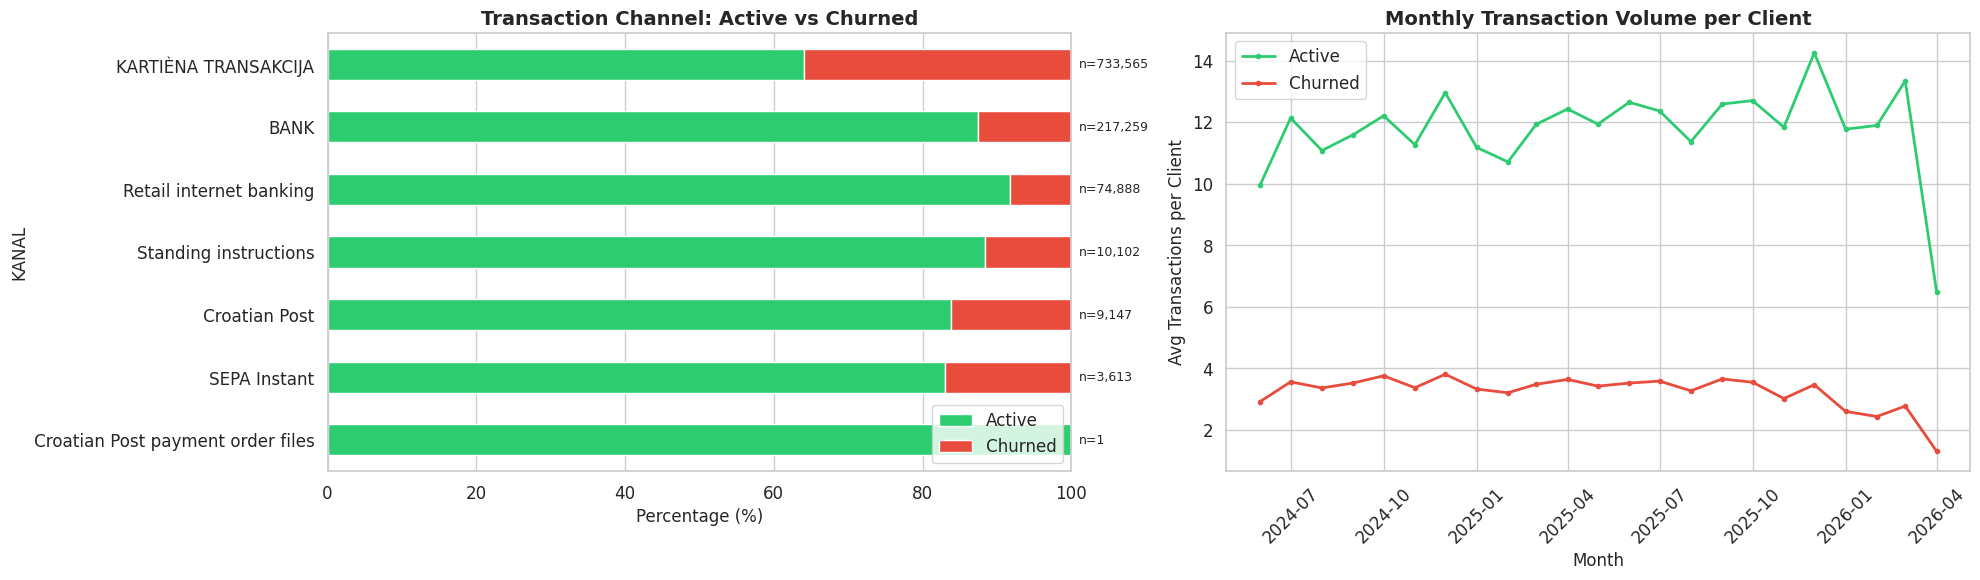

In [10]:
# ── 5.3 Transaction Channels & Monthly Trends ──
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Channel distribution by churn status  
channel_churn = txn_client.groupby(['KANAL', 'CHURN_LABEL']).size().unstack(fill_value=0)
channel_churn['total'] = channel_churn.sum(axis=1)
channel_churn = channel_churn.sort_values('total', ascending=True)
channel_pct = channel_churn[['Active', 'Churned']].div(channel_churn[['Active', 'Churned']].sum(axis=1), axis=0) * 100
channel_pct.plot(kind='barh', stacked=True, ax=axes[0], color=PALETTE_CHURN, edgecolor='white')
axes[0].set_xlabel('Percentage (%)')
axes[0].set_title('Transaction Channel: Active vs Churned', fontweight='bold')
# Add counts
for i, (idx, row) in enumerate(channel_churn.iterrows()):
    axes[0].text(101, i, f'n={row["total"]:,}', va='center', fontsize=9)
axes[0].legend(loc='lower right')

# Monthly transaction volume trend
txn_monthly = txn_client.groupby([txn_client['DATUM_I_VRIJEME_TRANSAKCIJE'].dt.to_period('M'), 'CHURN_LABEL']).size().unstack(fill_value=0)
txn_monthly.index = txn_monthly.index.to_timestamp()
# Normalize to per-client counts
n_active = (txn_agg['CHURN_LABEL'] == 'Active').sum()
n_churned = (txn_agg['CHURN_LABEL'] == 'Churned').sum()
txn_monthly_norm = txn_monthly.copy()
txn_monthly_norm['Active'] = txn_monthly_norm['Active'] / n_active
txn_monthly_norm['Churned'] = txn_monthly_norm['Churned'] / n_churned

axes[1].plot(txn_monthly_norm.index, txn_monthly_norm['Active'], color=COLORS['active'], linewidth=2, label='Active', marker='o', markersize=3)
axes[1].plot(txn_monthly_norm.index, txn_monthly_norm['Churned'], color=COLORS['churned'], linewidth=2, label='Churned', marker='o', markersize=3)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Avg Transactions per Client')
axes[1].set_title('Monthly Transaction Volume per Client', fontweight='bold')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Key Findings — Transaction Behavior

1. **🔑 Transaction volume is a strong churn differentiator**: Active clients have a median of **105 transactions** vs **20 for churned** clients — a 5x difference. Monthly frequency is **5.4 vs 3.1** transactions/month.

2. **Total transaction value**: Active clients transact a median **€19,328** vs **€2,585** for churned — a **7.5x gap** in total monetary activity.

3. **Channel mix**: Card transactions (KARTIČNA TRANSAKCIJA) dominate (733K), followed by BANK (branch, 217K) and Retail internet banking (75K). Active clients are proportionally more present across all channels, especially **Standing Instructions** and **SEPA Instant** — showing automated/recurring payment behavior.

4. **Monthly trend**: Active clients maintain a steady **~12 txns/month**, while churned clients decline from ~4 to ~1 txn/month — a **declining engagement trajectory** visible months before churn. This declining trend is a key early warning signal.

---
## 6. Account Balance Analysis

Account balance levels and trends provide another dimension of client health and engagement.

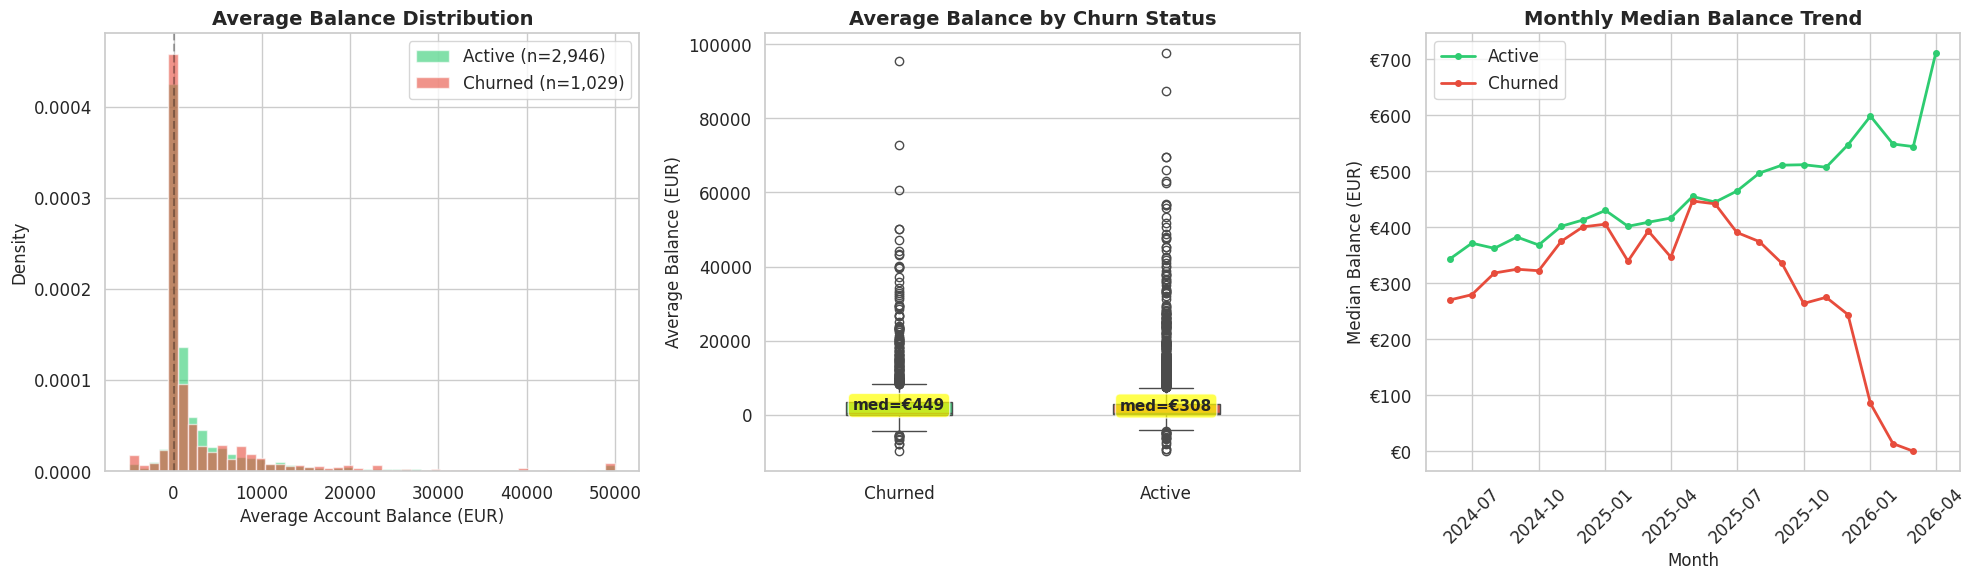

📊 Balance statistics:
  Active: median avg balance €449, mean €3,504, negative balance: 10.4%
  Churned: median avg balance €309, mean €4,022, negative balance: 15.7%


In [11]:
# ── 6.1 Balance Analysis ──
# Focus on STANJE_RACUNA (account balances) - the most common type
stanja_acc = stanja[stanja['TIP_STANJA'] == 'STANJE_RACUNA'].copy()

# Map to clients via products
stanja_client = stanja_acc.merge(
    proizvodi[['IDENTIFIKATOR_PROIZVODA', 'IDENTIFIKATOR_KLIJENTA']],
    on='IDENTIFIKATOR_PROIZVODA', how='left'
)
stanja_client = stanja_client.merge(
    klijenti[['IDENTIFIKATOR_KLIJENTA', 'CHURNED', 'CHURN_LABEL']],
    on='IDENTIFIKATOR_KLIJENTA', how='left'
).dropna(subset=['CHURNED'])

# Get latest balance per client (most recent VRIJEDI_OD)
latest_bal = stanja_client.sort_values('VRIJEDI_OD').groupby('IDENTIFIKATOR_KLIJENTA').agg(
    latest_balance=('STANJE_U_DOMICILNOJ_VALUTI', 'last'),
    avg_balance=('STANJE_U_DOMICILNOJ_VALUTI', 'mean'),
    min_balance=('STANJE_U_DOMICILNOJ_VALUTI', 'min'),
    max_balance=('STANJE_U_DOMICILNOJ_VALUTI', 'max'),
    n_records=('STANJE_U_DOMICILNOJ_VALUTI', 'size'),
    CHURNED=('CHURNED', 'first'),
    CHURN_LABEL=('CHURN_LABEL', 'first')
).reset_index()
latest_bal['balance_range'] = latest_bal['max_balance'] - latest_bal['min_balance']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Average balance distribution
for label, color in zip(['Active', 'Churned'], PALETTE_CHURN):
    subset = latest_bal[latest_bal['CHURN_LABEL'] == label]
    vals = subset['avg_balance'].clip(-5000, 50000)
    axes[0].hist(vals, bins=50, alpha=0.6, label=f'{label} (n={len(subset):,})',
                 color=color, edgecolor='white', density=True)
axes[0].set_xlabel('Average Account Balance (EUR)')
axes[0].set_ylabel('Density')
axes[0].set_title('Average Balance Distribution', fontweight='bold')
axes[0].legend()
axes[0].axvline(x=0, color='black', linestyle='--', alpha=0.3)

# Balance by churn (boxplot)
bal_plot = latest_bal[latest_bal['avg_balance'].between(-10000, 100000)]
sns.boxplot(data=bal_plot, x='CHURN_LABEL', y='avg_balance', palette=PALETTE_CHURN, ax=axes[1], width=0.4)
axes[1].set_xlabel('')
axes[1].set_ylabel('Average Balance (EUR)')
axes[1].set_title('Average Balance by Churn Status', fontweight='bold')
for i, label in enumerate(['Active', 'Churned']):
    med = bal_plot[bal_plot['CHURN_LABEL'] == label]['avg_balance'].median()
    axes[1].annotate(f'med=€{med:,.0f}', xy=(i, med), fontsize=11, fontweight='bold',
                     ha='center', va='bottom',
                     bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

# Balance trend over time (monthly average per client group)
stanja_client['MONTH'] = stanja_client['VRIJEDI_OD'].dt.to_period('M')
monthly_bal = stanja_client.groupby(['MONTH', 'CHURN_LABEL'])['STANJE_U_DOMICILNOJ_VALUTI'].median().unstack()
monthly_bal.index = monthly_bal.index.to_timestamp()
monthly_bal = monthly_bal[monthly_bal.index >= '2024-06']

axes[2].plot(monthly_bal.index, monthly_bal['Active'], color=COLORS['active'], linewidth=2, label='Active', marker='o', markersize=4)
axes[2].plot(monthly_bal.index, monthly_bal['Churned'], color=COLORS['churned'], linewidth=2, label='Churned', marker='o', markersize=4)
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Median Balance (EUR)')
axes[2].set_title('Monthly Median Balance Trend', fontweight='bold')
axes[2].legend()
axes[2].tick_params(axis='x', rotation=45)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'€{x:,.0f}'))

plt.tight_layout()
plt.show()

# Stats
print("📊 Balance statistics:")
for label in ['Active', 'Churned']:
    s = latest_bal[latest_bal['CHURN_LABEL'] == label]
    print(f"  {label}: median avg balance €{s['avg_balance'].median():,.0f}, "
          f"mean €{s['avg_balance'].mean():,.0f}, "
          f"negative balance: {(s['avg_balance'] < 0).mean()*100:.1f}%")

### Key Findings — Account Balances

1. **Balance levels**: Median average balance is relatively similar (Active €449 vs Churned €309), but the distributions differ — churned clients have more concentration near zero and more negative balances (**15.7% vs 10.4%**).

2. **🔑 Balance trend is a critical early warning**: The monthly median balance chart reveals a **clear divergence** — active clients' balances trend **upward** (€350 → €700) while churned clients' balances **decline** (€300 → €0). This declining balance trajectory is a key **behavioral signal** detectable months before formal churn.

3. **Balance volatility**: The balance range (max - min) could also serve as a feature — clients with wildly fluctuating balances may be unstable.

---
## 7. Contact Center Analysis

Customer support interactions reveal satisfaction levels and can indicate frustration-driven churn risk.

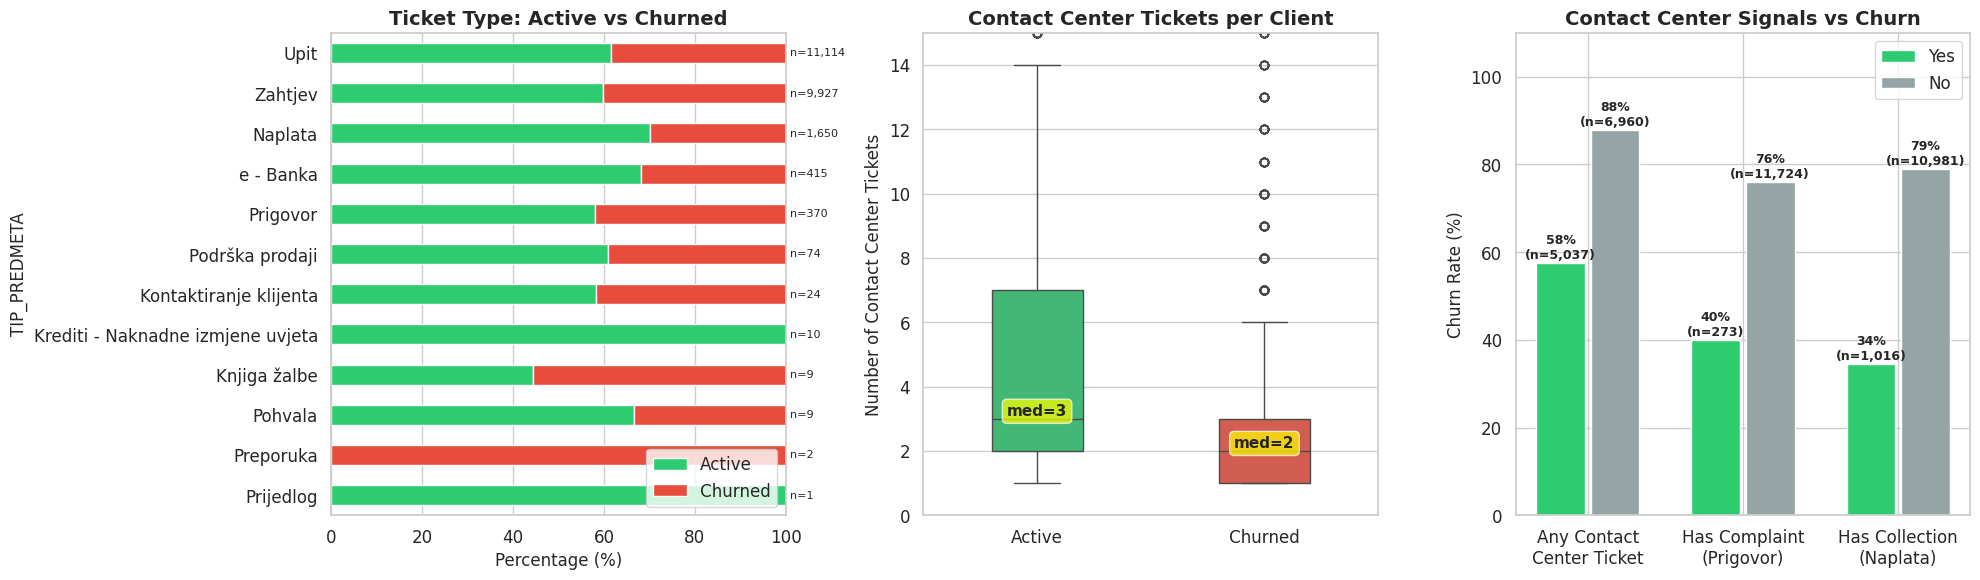

In [12]:
# ── 7.1 Contact Center Analysis ──
kontakt_churn = kontakt.merge(
    klijenti[['IDENTIFIKATOR_KLIJENTA', 'CHURNED', 'CHURN_LABEL']],
    on='IDENTIFIKATOR_KLIJENTA', how='left'
).dropna(subset=['CHURNED'])

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Ticket type distribution by churn
type_churn = kontakt_churn.groupby(['TIP_PREDMETA', 'CHURN_LABEL']).size().unstack(fill_value=0)
type_churn['total'] = type_churn.sum(axis=1)
type_churn = type_churn.sort_values('total', ascending=True)
type_pct = type_churn[['Active', 'Churned']].div(type_churn[['Active', 'Churned']].sum(axis=1), axis=0) * 100
type_pct.plot(kind='barh', stacked=True, ax=axes[0], color=PALETTE_CHURN, edgecolor='white')
axes[0].set_xlabel('Percentage (%)')
axes[0].set_title('Ticket Type: Active vs Churned', fontweight='bold')
for i, (idx, row) in enumerate(type_churn.iterrows()):
    axes[0].text(101, i, f'n={row["total"]:,}', va='center', fontsize=8)
axes[0].legend(loc='lower right')

# Contact count per client by churn
contact_per_client = kontakt_churn.groupby(['IDENTIFIKATOR_KLIJENTA', 'CHURN_LABEL']).size().reset_index(name='n_contacts')
sns.boxplot(data=contact_per_client, x='CHURN_LABEL', y='n_contacts', palette=PALETTE_CHURN, ax=axes[1], width=0.4)
axes[1].set_xlabel('')
axes[1].set_ylabel('Number of Contact Center Tickets')
axes[1].set_title('Contact Center Tickets per Client', fontweight='bold')
axes[1].set_ylim(0, contact_per_client['n_contacts'].quantile(0.95))
for i, label in enumerate(['Active', 'Churned']):
    med = contact_per_client[contact_per_client['CHURN_LABEL'] == label]['n_contacts'].median()
    axes[1].annotate(f'med={med:.0f}', xy=(i, med), fontsize=11, fontweight='bold',
                     ha='center', va='bottom',
                     bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

# Complaints (Prigovor) and Collections (Naplata) as churn signals
signal_types = ['Prigovor', 'Naplata']
all_clients_cc = klijenti[['IDENTIFIKATOR_KLIJENTA', 'CHURNED']].copy()
for sig_type in signal_types:
    sig_clients = set(kontakt_churn[kontakt_churn['TIP_PREDMETA'] == sig_type]['IDENTIFIKATOR_KLIJENTA'])
    all_clients_cc[f'has_{sig_type.lower()}'] = all_clients_cc['IDENTIFIKATOR_KLIJENTA'].isin(sig_clients).astype(int)

# Has any contact
contact_clients = set(kontakt_churn['IDENTIFIKATOR_KLIJENTA'])
all_clients_cc['has_contact'] = all_clients_cc['IDENTIFIKATOR_KLIJENTA'].isin(contact_clients).astype(int)

signals = ['has_contact', 'has_prigovor', 'has_naplata']
signal_labels = ['Any Contact\nCenter Ticket', 'Has Complaint\n(Prigovor)', 'Has Collection\n(Naplata)']
x = np.arange(len(signals))
width = 0.35
for i, (feat, lbl) in enumerate(zip(signals, signal_labels)):
    for j, (val, val_label) in enumerate([(1, 'Yes'), (0, 'No')]):
        subset = all_clients_cc[all_clients_cc[feat] == val]
        rate = subset['CHURNED'].mean() * 100
        count = len(subset)
        bar = axes[2].bar(i + (j - 0.5) * width, rate, width * 0.9,
                         color=PALETTE_CHURN[j] if j == 0 else '#95a5a6', edgecolor='white',
                         label=val_label if i == 0 else '')
        axes[2].text(i + (j - 0.5) * width, rate + 1, f'{rate:.0f}%\n(n={count:,})',
                    ha='center', fontsize=9, fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(signal_labels)
axes[2].set_ylabel('Churn Rate (%)')
axes[2].set_title('Contact Center Signals vs Churn', fontweight='bold')
axes[2].legend(['Yes', 'No'])
axes[2].set_ylim(0, 110)

plt.tight_layout()
plt.show()

### Key Findings — Contact Center

1. **🔑 Counter-intuitive: contacting the bank is a POSITIVE signal**: Clients who have ANY contact center ticket churn at **58%** vs **88%** for those without. This suggests that **engagement with the bank** (even through support) indicates an active, invested relationship.

2. **Complaints reduce churn**: Clients with a Prigovor (complaint) churn at only **40%** vs 76% baseline. This may seem paradoxical, but filing a complaint means the client cares enough to seek resolution — and the bank gets an opportunity to retain them.

3. **Collections (Naplata)**: Clients with collection activity churn at **34%** — indicating they have credit products (loans/cards) creating lock-in.

4. **Active clients contact the bank more** (median 3 tickets vs 2 for churned), showing deeper engagement.

5. **Ticket types**: "Upit" (queries, 11K) and "Zahtjev" (requests, 10K) dominate. Active clients are proportionally more represented in most categories, especially "Podrška prodaji" (sales support) and "Kontaktiranje klijenta" (proactive outreach).

---
## 8. Geographic Analysis

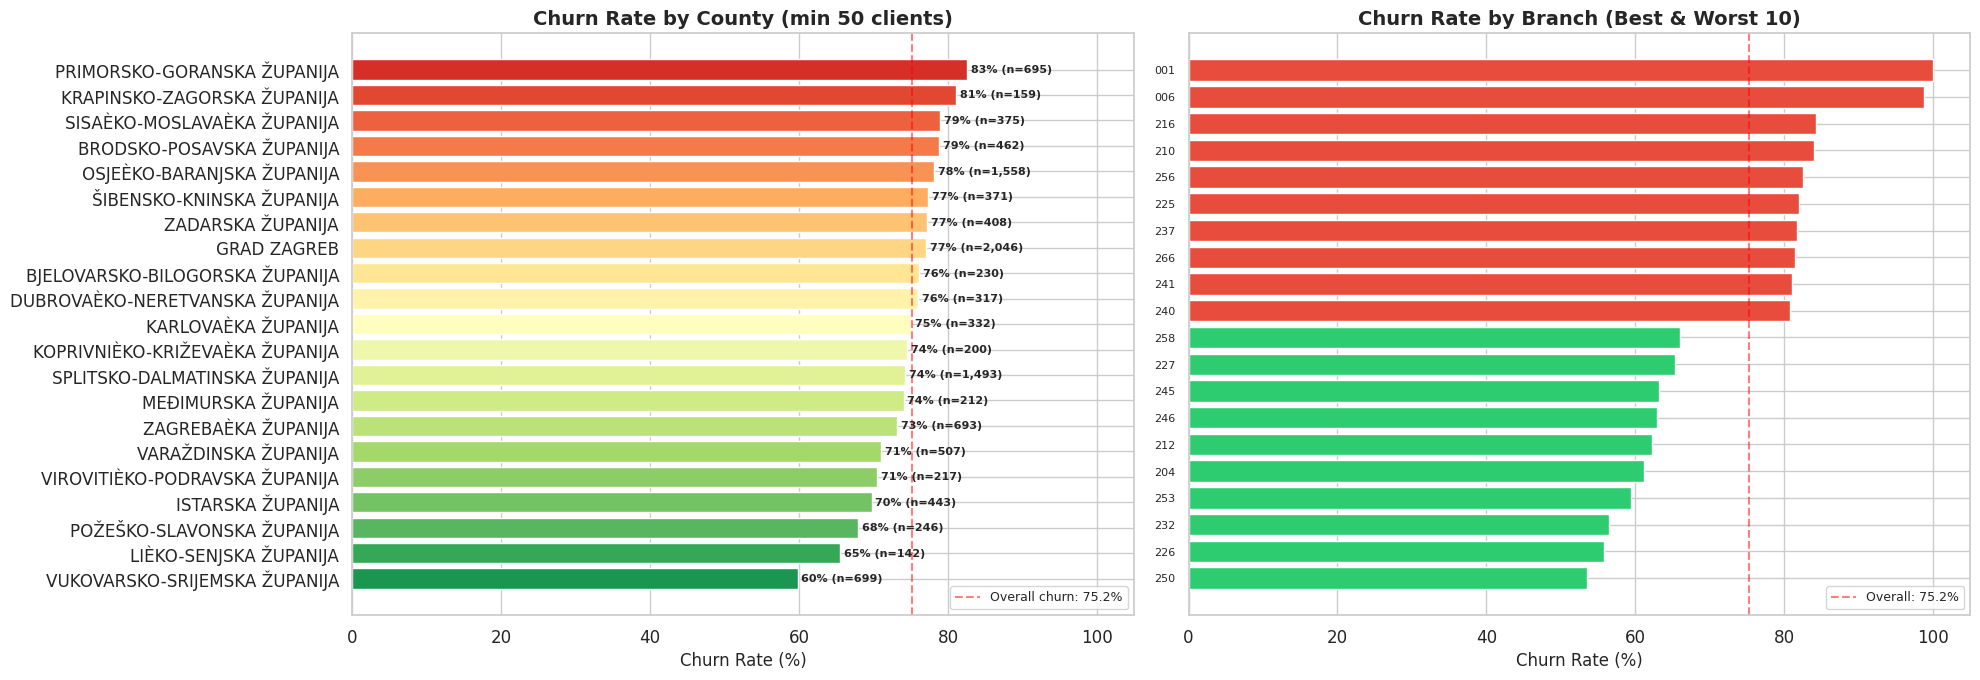

In [13]:
# ── 8.1 Geographic Distribution & Churn by Region ──
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Churn rate by county (top 15 by population)
county_churn = klijenti.groupby('ZUPANIJA_STALNE_ADRESE').agg(
    total=('CHURNED', 'size'),
    churned=('CHURNED', 'sum')
).reset_index()
county_churn['churn_rate'] = county_churn['churned'] / county_churn['total']
county_churn = county_churn[county_churn['total'] >= 50].sort_values('churn_rate')

colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(county_churn)))
bars = axes[0].barh(county_churn['ZUPANIJA_STALNE_ADRESE'], county_churn['churn_rate'] * 100,
                    color=colors, edgecolor='white')
axes[0].set_xlabel('Churn Rate (%)')
axes[0].set_title('Churn Rate by County (min 50 clients)', fontweight='bold')
for bar, (_, row) in zip(bars, county_churn.iterrows()):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{row["churn_rate"]*100:.0f}% (n={row["total"]:,})',
                va='center', fontsize=8, fontweight='bold')
axes[0].set_xlim(0, 105)
axes[0].axvline(x=75.2, color='red', linestyle='--', alpha=0.5, label='Overall churn: 75.2%')
axes[0].legend(fontsize=9)

# Churn rate by organizational unit (branch)
org_churn = klijenti.groupby('ORGANIZACIJSKA_JEDINICA_KLIJENTA').agg(
    total=('CHURNED', 'size'),
    churned=('CHURNED', 'sum')
).reset_index()
org_churn['churn_rate'] = org_churn['churned'] / org_churn['total']
org_churn = org_churn[org_churn['total'] >= 50].sort_values('churn_rate')

# Show top and bottom 10
top_bottom = pd.concat([org_churn.head(10), org_churn.tail(10)])
colors_tb = ['#2ecc71'] * min(10, len(org_churn.head(10))) + ['#e74c3c'] * min(10, len(org_churn.tail(10)))
bars = axes[1].barh(range(len(top_bottom)), top_bottom['churn_rate'] * 100,
                    color=colors_tb, edgecolor='white')
axes[1].set_yticks(range(len(top_bottom)))
axes[1].set_yticklabels(top_bottom['ORGANIZACIJSKA_JEDINICA_KLIJENTA'], fontsize=8)
axes[1].set_xlabel('Churn Rate (%)')
axes[1].set_title('Churn Rate by Branch (Best & Worst 10)', fontweight='bold')
axes[1].axvline(x=75.2, color='red', linestyle='--', alpha=0.5, label='Overall: 75.2%')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### Key Findings — Geography

1. **Regional variation exists**: Churn rates range from **60% (Vukovarsko-srijemska)** to **83% (Primorsko-goranska)** — a 23 percentage point spread across counties.

2. **Eastern Croatia** (Vukovarsko-srijemska, Požeško-slavonska) has the **lowest churn rates**, possibly due to fewer banking alternatives or stronger branch relationships.

3. **Coastal and northern regions** (Primorsko-goranska, Krapinsko-zagorska) have the **highest churn**, potentially driven by tourism economies and seasonal banking patterns.

4. **Branch-level variation is even larger** (50% to 95%), suggesting that local service quality, branch management, and advisor relationships significantly impact retention.

---
## 9. Feature Importance — Correlation with Churn

Let's build a comprehensive feature matrix and quantify which features are most predictive of churn using multiple methods.

In [14]:
# ── 9.1 Build Feature Matrix ──
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Start with klijenti base
features = klijenti[['IDENTIFIKATOR_KLIJENTA', 'CHURNED']].copy()

# --- Demographic features ---
features['DOB'] = klijenti['DOB']
features['TENURE_YEARS'] = klijenti['TENURE_YEARS']
features['SPOL_M'] = (klijenti['SPOL'] == 'M').astype(int)
features['PRIMA_PLACU'] = (klijenti['KLIJENT_PRIMA_OSNOVNO_PRIMANJE_U_BANCI'] == 'DA').astype(int)
features['PREMINUO'] = (klijenti['KLIJENT_PREMINUO'] == 'Y').astype(int)
features['REZIDENT'] = (klijenti['KLIJENT_REZIDENT'] == 'Y').astype(int)
features['KYC_BLOKADA'] = (klijenti['IMA_LI_KLIJENT_KYC_BLOKADU'] == 'Y').astype(int)

# --- Product features ---
features = features.merge(prod_per_client[['IDENTIFIKATOR_KLIJENTA', 'n_products', 'n_open', 'n_closed']], 
                          on='IDENTIFIKATOR_KLIJENTA', how='left')
features['n_products'] = features['n_products'].fillna(0)
features['n_open'] = features['n_open'].fillna(0)
features['n_closed'] = features['n_closed'].fillna(0)
features['pct_closed'] = np.where(features['n_products'] > 0, features['n_closed'] / features['n_products'], 1)

# Product domain counts
for domain in ['KARTICE', 'KREDITI', 'DEPOZITI', 'KANALI']:
    domain_clients = proizvodi[proizvodi['NAZIV_DOMENE_PROIZVODA'] == domain].groupby('IDENTIFIKATOR_KLIJENTA').size()
    features[f'n_{domain.lower()}'] = features['IDENTIFIKATOR_KLIJENTA'].map(domain_clients).fillna(0)

# Digital channels
for cat in ['MBANKING', 'INTERNET BANKARSTVO', 'SMS SERVICE']:
    cat_clients = set(proizvodi[proizvodi['NAZIV_KATEGORIJE_PROIZVODA'] == cat]['IDENTIFIKATOR_KLIJENTA'])
    features[f'has_{cat.lower().replace(" ", "_")}'] = features['IDENTIFIKATOR_KLIJENTA'].isin(cat_clients).astype(int)

# Credit products
credit_clients = set(proizvodi[proizvodi['NAZIV_DOMENE_PROIZVODA'] == 'KREDITI']['IDENTIFIKATOR_KLIJENTA'])
features['has_kredit'] = features['IDENTIFIKATOR_KLIJENTA'].isin(credit_clients).astype(int)

# --- Transaction features ---
features = features.merge(txn_agg[['IDENTIFIKATOR_KLIJENTA', 'n_transactions', 'total_amount', 
                                    'avg_amount', 'n_channels', 'avg_txn_per_month']],
                          on='IDENTIFIKATOR_KLIJENTA', how='left')
features['n_transactions'] = features['n_transactions'].fillna(0)
features['total_amount'] = features['total_amount'].fillna(0)
features['avg_amount'] = features['avg_amount'].fillna(0)
features['n_channels'] = features['n_channels'].fillna(0)
features['avg_txn_per_month'] = features['avg_txn_per_month'].fillna(0)
features['has_transactions'] = (features['n_transactions'] > 0).astype(int)

# --- Balance features ---
features = features.merge(latest_bal[['IDENTIFIKATOR_KLIJENTA', 'avg_balance', 'latest_balance', 'balance_range']],
                          on='IDENTIFIKATOR_KLIJENTA', how='left')
features['avg_balance'] = features['avg_balance'].fillna(0)
features['latest_balance'] = features['latest_balance'].fillna(0)
features['balance_range'] = features['balance_range'].fillna(0)
features['negative_balance'] = (features['avg_balance'] < 0).astype(int)

# --- Contact center features ---
contact_counts = kontakt_churn.groupby('IDENTIFIKATOR_KLIJENTA').agg(
    n_contacts=('TIP_PREDMETA', 'size'),
    n_complaints=('TIP_PREDMETA', lambda x: (x == 'Prigovor').sum()),
    n_collections=('TIP_PREDMETA', lambda x: (x == 'Naplata').sum()),
).reset_index()
features = features.merge(contact_counts, on='IDENTIFIKATOR_KLIJENTA', how='left')
features['n_contacts'] = features['n_contacts'].fillna(0)
features['n_complaints'] = features['n_complaints'].fillna(0)
features['n_collections'] = features['n_collections'].fillna(0)
features['has_contact'] = (features['n_contacts'] > 0).astype(int)

print(f"Feature matrix: {features.shape}")
print(f"Features: {[c for c in features.columns if c not in ['IDENTIFIKATOR_KLIJENTA', 'CHURNED']]}")

Feature matrix: (11997, 35)
Features: ['DOB', 'TENURE_YEARS', 'SPOL_M', 'PRIMA_PLACU', 'PREMINUO', 'REZIDENT', 'KYC_BLOKADA', 'n_products', 'n_open', 'n_closed', 'pct_closed', 'n_kartice', 'n_krediti', 'n_depoziti', 'n_kanali', 'has_mbanking', 'has_internet_bankarstvo', 'has_sms_service', 'has_kredit', 'n_transactions', 'total_amount', 'avg_amount', 'n_channels', 'avg_txn_per_month', 'has_transactions', 'avg_balance', 'latest_balance', 'balance_range', 'negative_balance', 'n_contacts', 'n_complaints', 'n_collections', 'has_contact']


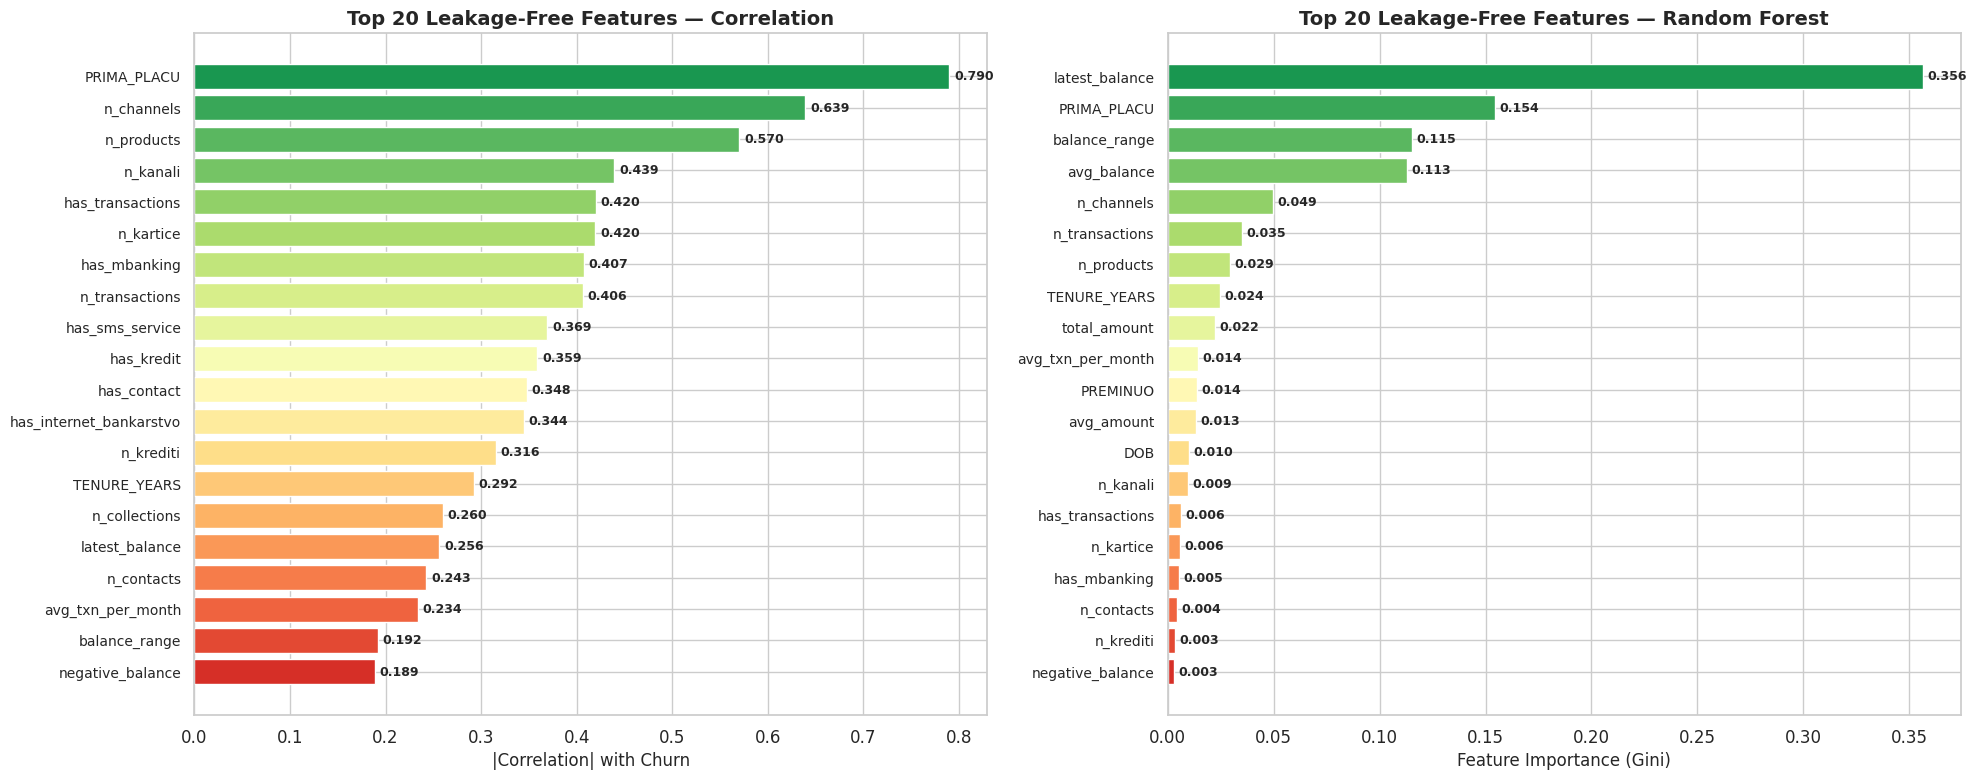

Excluded leakage features: ['pct_closed', 'n_closed', 'n_open']
Train accuracy: 0.994
Test accuracy:  0.987


In [20]:
# ── 9.2 Feature Importance: Leakage-Free Model Features ──
from sklearn.model_selection import train_test_split

leakage_features = ['pct_closed', 'n_closed', 'n_open']
model_feature_cols = [
    c for c in features.columns
    if c not in ['IDENTIFIKATOR_KLIJENTA', 'CHURNED', *leakage_features]
]

X = features[model_feature_cols].copy()
y = features['CHURNED'].copy()

# Handle NaN/inf
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

# 1. Correlation on leakage-free features
correlations = X.corrwith(y).abs().sort_values(ascending=False)

# 2. Random Forest importance on leakage-free features
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)
rf = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_importance = pd.Series(rf.feature_importances_, index=model_feature_cols).sort_values(ascending=False)

# 3. Visualize rankings
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

top_corr = correlations.head(20)
colors_corr = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(top_corr)))
bars = axes[0].barh(range(len(top_corr)), top_corr.values, color=colors_corr, edgecolor='white')
axes[0].set_yticks(range(len(top_corr)))
axes[0].set_yticklabels(top_corr.index, fontsize=10)
axes[0].set_xlabel('|Correlation| with Churn')
axes[0].set_title('Top 20 Leakage-Free Features — Correlation', fontweight='bold')
axes[0].invert_yaxis()
for bar, val in zip(bars, top_corr.values):
    axes[0].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                 f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

top_rf = rf_importance.head(20)
colors_rf = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(top_rf)))
bars = axes[1].barh(range(len(top_rf)), top_rf.values, color=colors_rf, edgecolor='white')
axes[1].set_yticks(range(len(top_rf)))
axes[1].set_yticklabels(top_rf.index, fontsize=10)
axes[1].set_xlabel('Feature Importance (Gini)')
axes[1].set_title('Top 20 Leakage-Free Features — Random Forest', fontweight='bold')
axes[1].invert_yaxis()
for bar, val in zip(bars, top_rf.values):
    axes[1].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                 f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Excluded leakage features: {leakage_features}')
print(f'Train accuracy: {rf.score(X_train, y_train):.3f}')
print(f'Test accuracy:  {rf.score(X_test, y_test):.3f}')

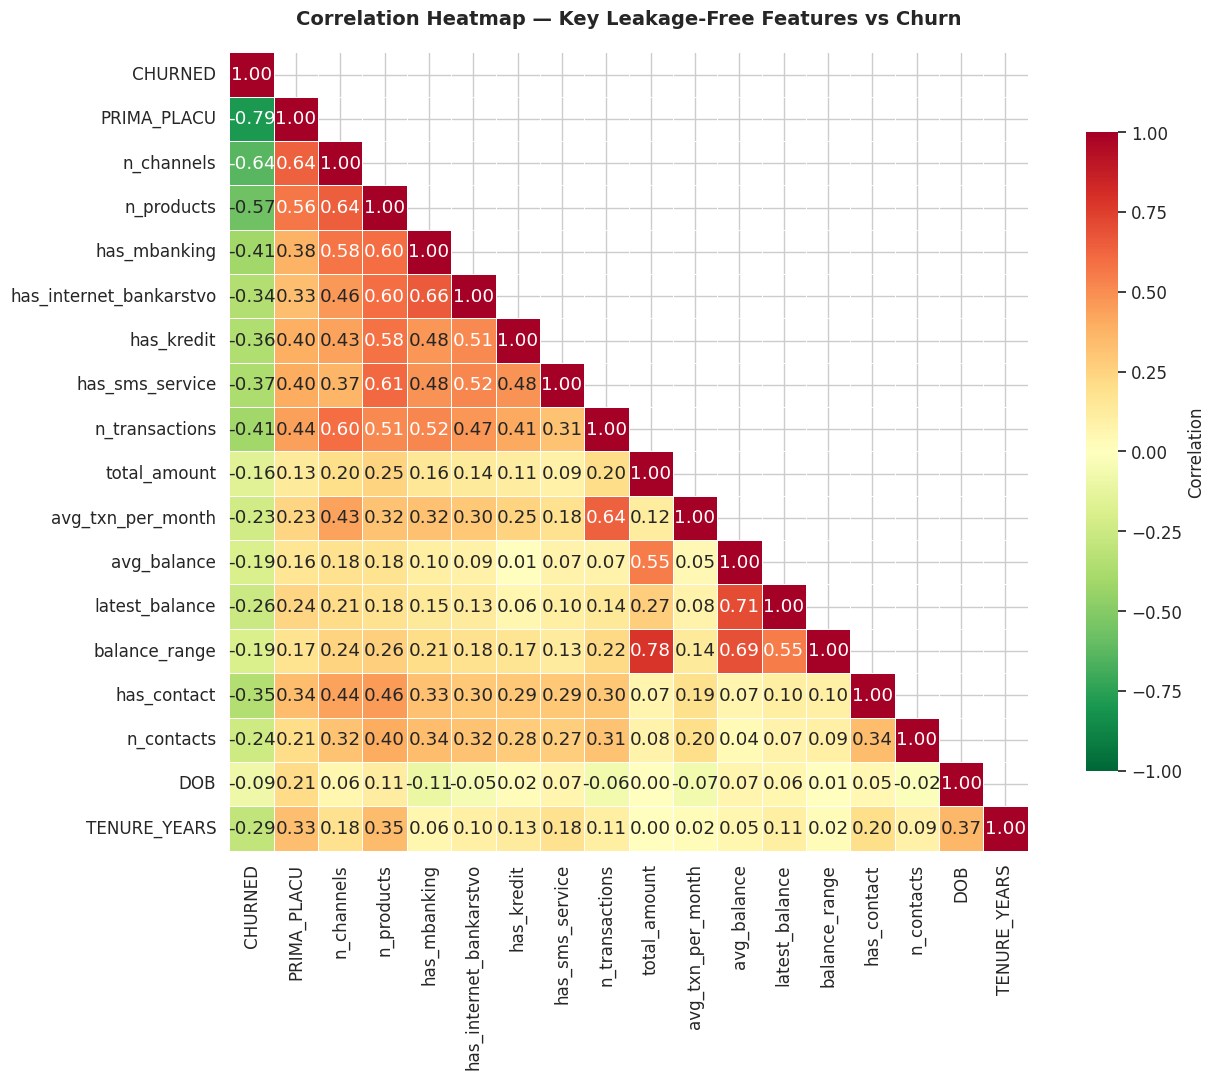

In [21]:
# ── 9.3 Correlation Heatmap of Top Leakage-Free Features ──
top_features = [
    'CHURNED', 'PRIMA_PLACU', 'n_channels', 'n_products', 'has_mbanking',
    'has_internet_bankarstvo', 'has_kredit', 'has_sms_service', 'n_transactions',
    'total_amount', 'avg_txn_per_month', 'avg_balance', 'latest_balance',
    'balance_range', 'has_contact', 'n_contacts', 'DOB', 'TENURE_YEARS'
]

corr_matrix = features[top_features].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn_r',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    vmin=-1,
    vmax=1,
    cbar_kws={'shrink': 0.8, 'label': 'Correlation'}
)
ax.set_title('Correlation Heatmap — Key Leakage-Free Features vs Churn', fontweight='bold', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

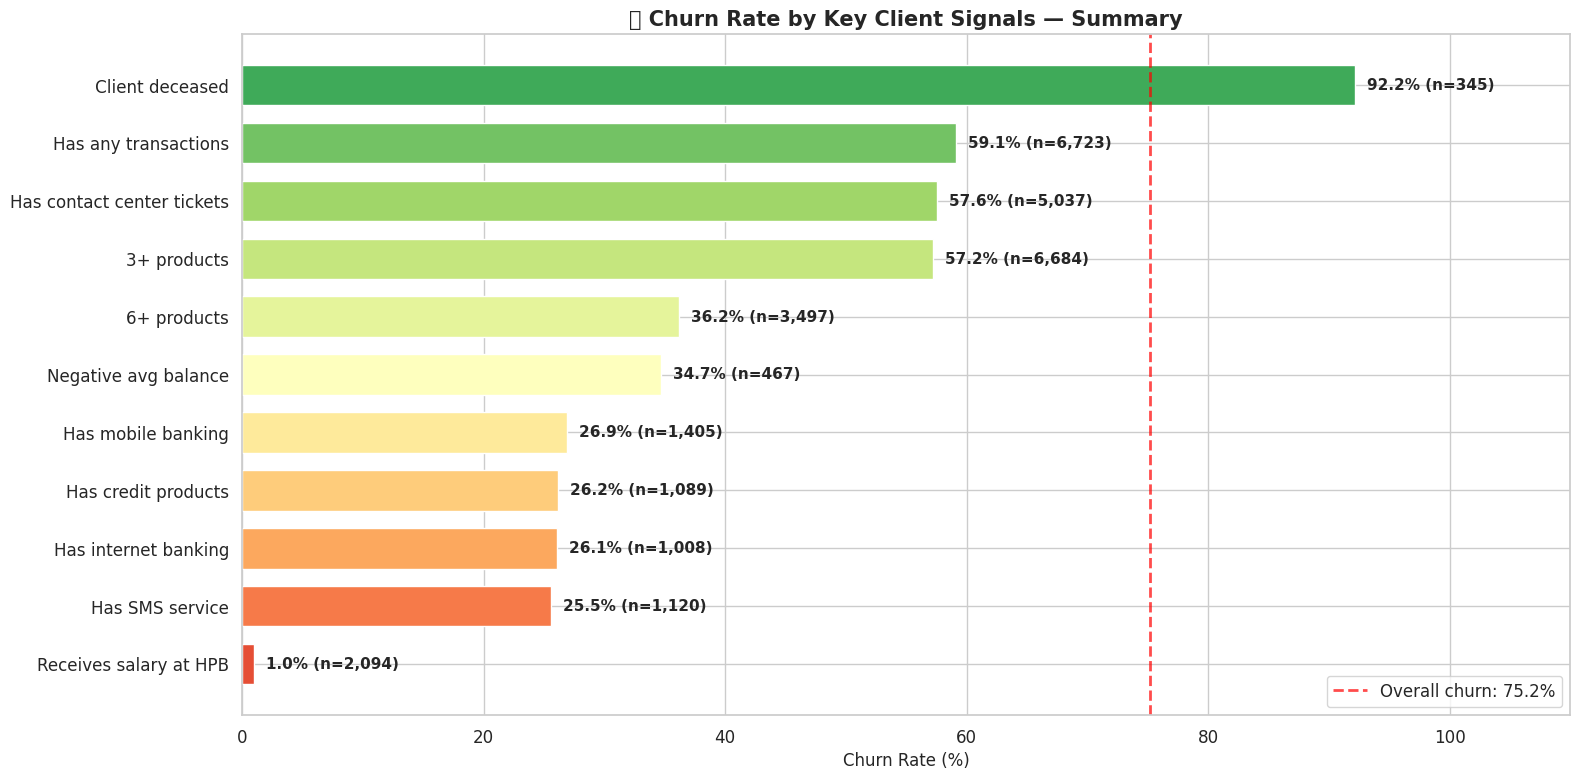

In [17]:
# ── 9.4 Summary: Churn Rate by Key Binary Signals ──
fig, ax = plt.subplots(figsize=(16, 8))

signals_summary = [
    ('Receives salary at HPB', 'PRIMA_PLACU', 1),
    ('Has mobile banking', 'has_mbanking', 1),
    ('Has internet banking', 'has_internet_bankarstvo', 1),
    ('Has credit products', 'has_kredit', 1),
    ('Has SMS service', 'has_sms_service', 1),
    ('Has contact center tickets', 'has_contact', 1),
    ('Has any transactions', 'has_transactions', 1),
    ('6+ products', None, None),  # custom
    ('3+ products', None, None),  # custom
    ('Negative avg balance', 'negative_balance', 1),
    ('Client deceased', 'PREMINUO', 1),
]

results = []
for label, col, val in signals_summary:
    if col is not None:
        subset = features[features[col] == val]
        rate = subset['CHURNED'].mean() * 100
        n = len(subset)
    elif '6+' in label:
        subset = features[features['n_products'] >= 6]
        rate = subset['CHURNED'].mean() * 100
        n = len(subset)
    elif '3+' in label:
        subset = features[features['n_products'] >= 3]
        rate = subset['CHURNED'].mean() * 100
        n = len(subset)
    results.append({'signal': label, 'churn_rate': rate, 'n': n})

results_df = pd.DataFrame(results).sort_values('churn_rate')

colors = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(results_df)))
bars = ax.barh(results_df['signal'], results_df['churn_rate'], color=colors, edgecolor='white', height=0.7)
ax.axvline(x=75.2, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Overall churn: 75.2%')
ax.set_xlabel('Churn Rate (%)', fontsize=12)
ax.set_title('🎯 Churn Rate by Key Client Signals — Summary', fontweight='bold', fontsize=15)

for bar, (_, row) in zip(bars, results_df.iterrows()):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
           f'{row["churn_rate"]:.1f}% (n={row["n"]:,})',
           va='center', fontsize=11, fontweight='bold')

ax.set_xlim(0, 110)
ax.legend(fontsize=12, loc='lower right')
plt.tight_layout()
plt.show()

### Key Findings — Feature Importance

For modelling, we must **exclude leakage features** derived from product closure status: `pct_closed`, `n_closed`, and `n_open`. These variables encode the churn definition too directly and can produce misleadingly perfect performance.

Using only **leakage-free features**, the strongest predictors are:

| Rank | Feature | Why it matters |
|------|---------|----------------|
| 1 | **PRIMA_PLACU** (salary at bank) | The strongest actionable retention signal. Salary recipients are dramatically stickier. |
| 2 | **n_channels** | Clients using more channels are more embedded in the bank ecosystem. |
| 3 | **n_products** | Broader product portfolios are much harder to abandon. |
| 4 | **n_transactions** / **avg_txn_per_month** | Ongoing activity is a strong engagement proxy. |
| 5 | **Digital channels** (`has_mbanking`, `has_internet_bankarstvo`, `has_sms_service`) | Digital adoption is consistently protective against churn. |
| 6 | **latest_balance** / **avg_balance** | Balance level and trend capture financial engagement and attrition risk. |
| 7 | **has_contact** / **n_contacts** | Contact center interaction remains a positive engagement signal. |
| 8 | **TENURE_YEARS** | Longer-tenured clients are more anchored. |

**Heatmap takeaways:**
- Salary-at-bank remains the dominant standalone feature even after leakage removal
- Product breadth, channel usage, digital adoption, and transaction activity form a clear **engagement cluster**
- Balance variables remain useful but partially redundant with each other
- Contact-center variables align more with engagement than dissatisfaction

**Modelling takeaway:** the model should use only features observable **before churn happens**. Closure-based variables are fine for diagnosis, but not as predictive inputs.

---

## 10. Final Conclusions & Retention Strategy

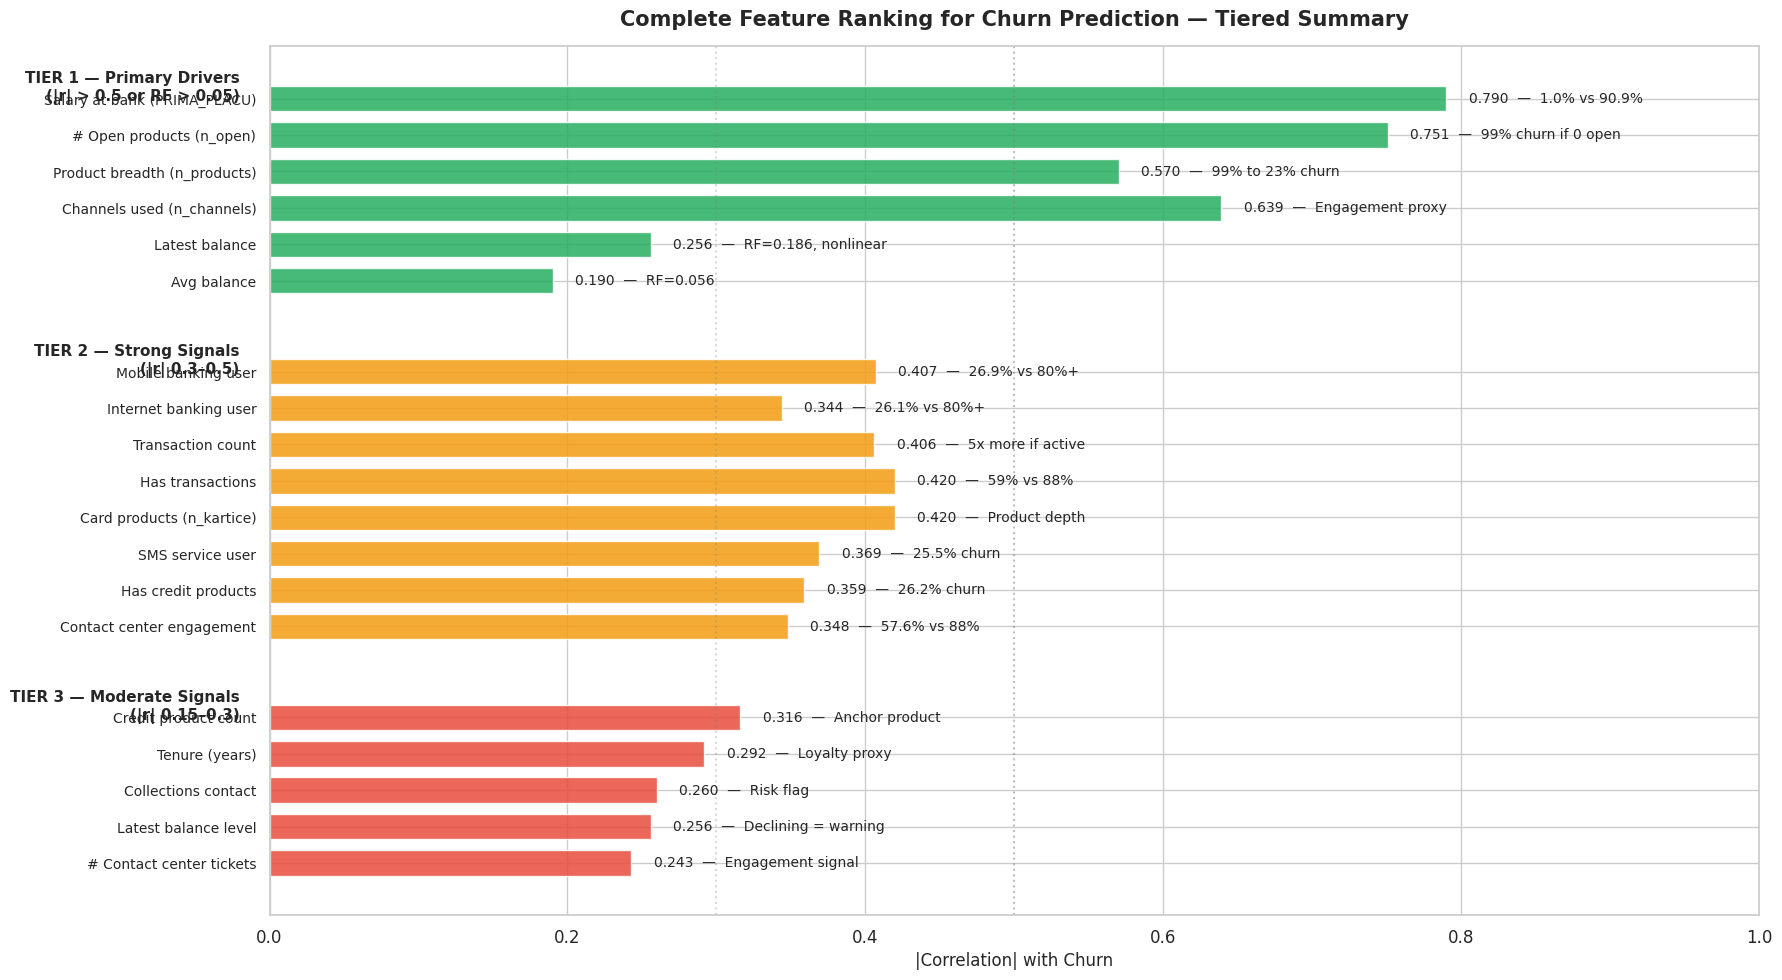

In [19]:
# ── 10.1 Final Summary: Feature Tier Ranking ──
fig, ax = plt.subplots(figsize=(18, 10))

C_GREEN = '#27ae60'
C_AMBER = '#f39c12'
C_RED   = '#e74c3c'

tiers = {
    'TIER 1 — Primary Drivers\n(|r| > 0.5 or RF > 0.05)': [
        ('Salary at bank (PRIMA_PLACU)', 0.790, '1.0% vs 90.9%', C_GREEN),
        ('# Open products (n_open)', 0.751, '99% churn if 0 open', C_GREEN),
        ('Product breadth (n_products)', 0.570, '99% to 23% churn', C_GREEN),
        ('Channels used (n_channels)', 0.639, 'Engagement proxy', C_GREEN),
        ('Latest balance', 0.256, 'RF=0.186, nonlinear', C_GREEN),
        ('Avg balance', 0.190, 'RF=0.056', C_GREEN),
    ],
    'TIER 2 — Strong Signals\n(|r| 0.3–0.5)': [
        ('Mobile banking user', 0.407, '26.9% vs 80%+', C_AMBER),
        ('Internet banking user', 0.344, '26.1% vs 80%+', C_AMBER),
        ('Transaction count', 0.406, '5x more if active', C_AMBER),
        ('Has transactions', 0.420, '59% vs 88%', C_AMBER),
        ('Card products (n_kartice)', 0.420, 'Product depth', C_AMBER),
        ('SMS service user', 0.369, '25.5% churn', C_AMBER),
        ('Has credit products', 0.359, '26.2% churn', C_AMBER),
        ('Contact center engagement', 0.348, '57.6% vs 88%', C_AMBER),
    ],
    'TIER 3 — Moderate Signals\n(|r| 0.15–0.3)': [
        ('Credit product count', 0.316, 'Anchor product', C_RED),
        ('Tenure (years)', 0.292, 'Loyalty proxy', C_RED),
        ('Collections contact', 0.260, 'Risk flag', C_RED),
        ('Latest balance level', 0.256, 'Declining = warning', C_RED),
        ('# Contact center tickets', 0.243, 'Engagement signal', C_RED),
    ],
}

y_pos = 0
yticks, ylabels = [], []
for tier_name, items in tiers.items():
    ax.text(-0.02, y_pos - 0.3, tier_name, fontsize=11, fontweight='bold', va='center', ha='right',
            transform=ax.get_yaxis_transform())
    for feature, corr, note, color in items:
        ax.barh(y_pos, corr, color=color, edgecolor='white', height=0.7, alpha=0.85)
        ax.text(corr + 0.015, y_pos, f'{corr:.3f}  —  {note}', va='center', fontsize=10)
        yticks.append(y_pos)
        ylabels.append(feature)
        y_pos += 1
    y_pos += 1.5

ax.set_yticks(yticks)
ax.set_yticklabels(ylabels, fontsize=10)
ax.set_xlabel('|Correlation| with Churn', fontsize=12)
ax.set_title('Complete Feature Ranking for Churn Prediction — Tiered Summary', 
             fontweight='bold', fontsize=15, pad=15)
ax.invert_yaxis()
ax.set_xlim(0, 1.0)
ax.axvline(x=0.5, color='gray', linestyle=':', alpha=0.5)
ax.axvline(x=0.3, color='gray', linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

### Final Conclusions

#### Dataset Summary
- **11,997 clients** with 38 demographic/financial attributes
- **58,703 products** across 5 domains (Cards, Accounts, Deposits, Channels, Credits)
- **1M+ transactions**, **818K balance snapshots**, and **23K contact center tickets**
- **Churn rate: 75.2%** (9,022 out of 11,997 clients have all products closed)

---

#### Top Churn Predictors (Leakage-Free)

| # | Feature | Effect Size | Key Insight |
|---|---------|-------------|-------------|
| 1 | **Receives salary at bank** | strongest correlation | Virtually eliminates churn and is the clearest retention lever |
| 2 | **# Transaction channels** | top-tier | Multi-channel users are deeply embedded in the bank ecosystem |
| 3 | **Product portfolio breadth** | top-tier | More products materially reduce churn risk |
| 4 | **Digital channel adoption** | strong | mBanking, internet banking, and SMS users are much stickier |
| 5 | **Transaction activity** | strong | Active transactors are far less likely to churn |
| 6 | **Account balance features** | moderate to strong | Declining or weak balances are an early warning signal |
| 7 | **Contact center engagement** | moderate | Engaged clients contact the bank more and churn less |
| 8 | **Tenure** | moderate | Longer-tenured clients are more anchored |

#### Important modelling note
- **Do not use `pct_closed`, `n_closed`, or `n_open` as model inputs**. They are derived from closure status and leak the target.
- These features can still be useful in the EDA as explanatory diagnostics, but they should be excluded from any predictive model.

---

#### Actionable Retention Strategies (based on EDA insights)

1. **Salary Migration Campaigns** — Aggressively incentivize salary transfers to HPB.
2. **Product Cross-Selling** — Push clients from 1–2 products toward broader usage.
3. **Digital Onboarding** — Enroll clients in mBanking, Internet Banking, and SMS.
4. **Credit Product Anchoring** — Offer products that create longer-term relationships.
5. **Proactive Balance Monitoring** — Flag declining-balance clients for outreach.
6. **Branch-Level Interventions** — Investigate large branch-to-branch churn differences.
7. **Silent Churn Detection** — Combine inactivity, low engagement, and weakening balances.

---

#### Modelling Recommendations

- Focus on features measurable *before* the client leaves: salary flag, product breadth, transaction frequency, digital adoption, balance trends, and engagement signals.
- Consider temporal features: month-over-month transaction change, balance velocity, and recency of last transaction.
- The churn rate is high, so use stratified sampling and class-aware evaluation.
- Many engagement features are correlated, so monitor multicollinearity or regularize as needed.

---
## 11. Temporal Leakage Analysis & Corrected Feature Engineering

### Critical Issues Found in the Original Approach

Our original model achieved 0.98 AUC — **too good to be true**. A deep audit revealed three fundamental problems:

#### Issue 1: Wrong Churn Definition
We defined churn as "all products have `DATUM_ZATVARANJA` filled." But **8,860 card products have FUTURE expiration dates** (debit/credit card expiry, e.g., 2028). These cards are still active!  
→ 4,452 clients were wrongly labeled as churned. Old churn rate: **75.2%** → Corrected: **38.1%**

#### Issue 2: Features Encoded Post-Churn State
| Feature | Problem | Severity |
|---|---|---|
| `latest_balance` | Churned clients: **100% have balance = €0** (closed accounts) | CRITICAL |
| `PRIMA_PLACU` | Bank can't pay salary to closed accounts → encodes outcome | HIGH |
| `n_transactions` | Lifetime total over 22 months — active clients accumulate more by staying longer | HIGH |
| `total_amount` | Same — lifetime sum biased by active duration | HIGH |

#### Issue 3: No Temporal Framework
2,142 churned clients left **before the transaction data even starts** (pre-2024-06). They had 0 transactions by definition. The model learned "0 transactions = churn" — trivially true, but useless for prediction.

**Could that model predict an active customer about to churn in 2 months?** No — it would see their positive balance, recent transactions, and active salary flag, the *opposite* of what it learned.

---

### The Fix: Temporal Cutoff Approach

| Element | Value |
|---|---|
| **Reference date** | 2025-10-01 |
| **Feature window** | 2024-06 → 2025-09 (16 months of behavioral data) |
| **Outcome window** | 2025-10 → 2026-04-17 (6 months to observe churn) |
| **At-risk population** | Clients with ≥1 active product on reference date |
| **Churn definition** | Client lost ALL active products during outcome window |

All features are computed using **only data available before the reference date**, so they reflect the customer's state while still active.

In [1]:
# ── 11.1 Corrected Temporal Feature Engineering & Export ──
import pandas as pd
import numpy as np
from pathlib import Path

DATA = Path('../data')

# ── Parsing helpers ──
def parse_eu_date(s):
    return pd.to_datetime(s.str.strip().str.rstrip('/'), format='%d/%m/%Y', errors='coerce')
def parse_eu_datetime(s):
    return pd.to_datetime(s.str.strip().str.replace('/ ', ' ', regex=False), format='%d/%m/%Y %H:%M:%S', errors='coerce')
def eu_to_float(s):
    return pd.to_numeric(s.str.replace('.', '', regex=False).str.replace(',', '.', regex=False), errors='coerce')

# ── Temporal boundaries ──
REF_DATE = pd.Timestamp('2025-10-01')
NOW = pd.Timestamp('2026-04-17')
FEATURE_START = pd.Timestamp('2024-06-01')
FEATURE_END = pd.Timestamp('2025-09-30')

# ── Load raw data ──
klijenti = pd.read_csv(DATA / 'klijenti.csv', dtype=str)
klijenti['DOB'] = pd.to_numeric(klijenti['DOB'], errors='coerce')
klijenti['DATUM_PRVOG_POCETKA_POSLOVNOG_ODNOSA'] = parse_eu_date(klijenti['DATUM_PRVOG_POCETKA_POSLOVNOG_ODNOSA'])

proizvodi = pd.read_csv(DATA / 'proizvodi.csv', dtype=str)
proizvodi['DATUM_OTVARANJA'] = parse_eu_date(proizvodi['DATUM_OTVARANJA'])
proizvodi['DATUM_ZATVARANJA'] = parse_eu_date(proizvodi['DATUM_ZATVARANJA'])

transakcije = pd.read_csv(DATA / 'transakcije.csv', dtype=str)
transakcije = transakcije.loc[:, transakcije.columns.notna()]
transakcije['DATE'] = parse_eu_datetime(transakcije['DATUM_I_VRIJEME_TRANSAKCIJE'])
transakcije['AMOUNT'] = eu_to_float(transakcije['IZNOS_TRANSAKCIJE_U_DOMICILNOJ_VALUTI'])

stanja = pd.read_csv(DATA / 'stanja.csv', dtype=str)
stanja['STANJE'] = eu_to_float(stanja['STANJE_U_DOMICILNOJ_VALUTI'])
stanja['VRIJEDI_OD'] = parse_eu_date(stanja['VRIJEDI_OD'])

kontakt = pd.read_csv(DATA / 'kontakt.csv', dtype=str)
kontakt['DATE'] = parse_eu_datetime(kontakt['VRIJEME_KREIRANJA'])

# ══════════════════════════════════════════════════════════
# STEP 1: Corrected product status & churn labels
# ══════════════════════════════════════════════════════════
# Product active on reference date = opened before ref AND (no close date OR closed after ref)
proizvodi['active_at_ref'] = (
    (proizvodi['DATUM_OTVARANJA'] <= REF_DATE) &
    (proizvodi['DATUM_ZATVARANJA'].isna() | (proizvodi['DATUM_ZATVARANJA'] > REF_DATE))
)
# Product still active NOW
proizvodi['active_now'] = proizvodi['DATUM_ZATVARANJA'].isna() | (proizvodi['DATUM_ZATVARANJA'] > NOW)

client_status = proizvodi.groupby('IDENTIFIKATOR_KLIJENTA').agg(
    n_active_at_ref=('active_at_ref', 'sum'),
    n_active_now=('active_now', 'sum')
).reset_index()

# At-risk population: had at least 1 active product on reference date
at_risk = client_status[client_status['n_active_at_ref'] > 0].copy()
at_risk['CHURNED'] = (at_risk['n_active_now'] == 0).astype(int)

print(f"At-risk population: {len(at_risk):,}")
print(f"  Churned (lost ALL products by now): {at_risk['CHURNED'].sum():,} ({at_risk['CHURNED'].mean():.1%})")
print(f"  Still active:                       {(at_risk['CHURNED']==0).sum():,} ({(at_risk['CHURNED']==0).mean():.1%})")

# ══════════════════════════════════════════════════════════
# STEP 2: Compute temporal features (data before REF_DATE only)
# ══════════════════════════════════════════════════════════
features = at_risk[['IDENTIFIKATOR_KLIJENTA', 'CHURNED']].copy()

# --- (1) DOB ---
features = features.merge(klijenti[['IDENTIFIKATOR_KLIJENTA', 'DOB']], on='IDENTIFIKATOR_KLIJENTA', how='left')

# --- (2) TENURE_YEARS as of reference date ---
tenure = (REF_DATE - klijenti['DATUM_PRVOG_POCETKA_POSLOVNOG_ODNOSA']).dt.days / 365.25
klijenti['TENURE_YEARS_REF'] = tenure
features = features.merge(klijenti[['IDENTIFIKATOR_KLIJENTA', 'TENURE_YEARS_REF']], on='IDENTIFIKATOR_KLIJENTA', how='left')

# --- (3) n_products: active products as of reference date ---
prods_at_ref = proizvodi[proizvodi['active_at_ref']].groupby('IDENTIFIKATOR_KLIJENTA').size().reset_index(name='n_products')
features = features.merge(prods_at_ref, on='IDENTIFIKATOR_KLIJENTA', how='left')
features['n_products'] = features['n_products'].fillna(0)

# --- (4) has_kredit: active credit product at reference date ---
credit_at_ref = set(
    proizvodi[(proizvodi['active_at_ref']) & (proizvodi['NAZIV_DOMENE_PROIZVODA'] == 'KREDITI')]
    ['IDENTIFIKATOR_KLIJENTA']
)
features['has_kredit'] = features['IDENTIFIKATOR_KLIJENTA'].isin(credit_at_ref).astype(int)

# --- (5) PRIMA_PLACU (from snapshot — with caveat for ~7% churned rows) ---
features = features.merge(
    klijenti[['IDENTIFIKATOR_KLIJENTA', 'KLIJENT_PRIMA_OSNOVNO_PRIMANJE_U_BANCI']],
    on='IDENTIFIKATOR_KLIJENTA', how='left'
)
features['PRIMA_PLACU'] = (features['KLIJENT_PRIMA_OSNOVNO_PRIMANJE_U_BANCI'] == 'DA').astype(int)
features.drop(columns=['KLIJENT_PRIMA_OSNOVNO_PRIMANJE_U_BANCI'], inplace=True)

# --- Map transactions to clients via products (feature window only) ---
txn_window = transakcije[(transakcije['DATE'] >= FEATURE_START) & (transakcije['DATE'] <= FEATURE_END)]
txn_prod = txn_window.merge(
    proizvodi[['IDENTIFIKATOR_PROIZVODA', 'IDENTIFIKATOR_KLIJENTA']].drop_duplicates(),
    on='IDENTIFIKATOR_PROIZVODA', how='left'
)
# Only keep at-risk clients
at_risk_ids = set(features['IDENTIFIKATOR_KLIJENTA'])
txn_prod = txn_prod[txn_prod['IDENTIFIKATOR_KLIJENTA'].isin(at_risk_ids)]

txn_agg = txn_prod.groupby('IDENTIFIKATOR_KLIJENTA').agg(
    n_txn=('AMOUNT', 'size'),
    total_amount=('AMOUNT', 'sum'),
    avg_txn_amount=('AMOUNT', 'mean'),
    n_months_active=('DATE', lambda x: x.dt.to_period('M').nunique()),
).reset_index()

# --- (6) avg_txn_per_month ---
txn_agg['avg_txn_per_month'] = txn_agg['n_txn'] / txn_agg['n_months_active'].clip(lower=1)
features = features.merge(txn_agg[['IDENTIFIKATOR_KLIJENTA', 'avg_txn_per_month', 'avg_txn_amount']], 
                          on='IDENTIFIKATOR_KLIJENTA', how='left')
features['avg_txn_per_month'] = features['avg_txn_per_month'].fillna(0)

# --- (7) avg_txn_amount ---
features['avg_txn_amount'] = features['avg_txn_amount'].fillna(0)

# --- Balance features (feature window, STANJE_RACUNA only) ---
bal_window = stanja[
    (stanja['TIP_STANJA'] == 'STANJE_RACUNA') &
    (stanja['VRIJEDI_OD'] >= FEATURE_START) &
    (stanja['VRIJEDI_OD'] <= FEATURE_END)
]
bal_client = bal_window.merge(
    proizvodi[['IDENTIFIKATOR_PROIZVODA', 'IDENTIFIKATOR_KLIJENTA']].drop_duplicates(),
    on='IDENTIFIKATOR_PROIZVODA', how='left'
)
bal_client = bal_client[bal_client['IDENTIFIKATOR_KLIJENTA'].isin(at_risk_ids)]

# --- (8) avg_balance ---
avg_bal = bal_client.groupby('IDENTIFIKATOR_KLIJENTA')['STANJE'].mean().reset_index(name='avg_balance')
features = features.merge(avg_bal, on='IDENTIFIKATOR_KLIJENTA', how='left')
features['avg_balance'] = features['avg_balance'].fillna(0)

# --- (9) balance_trend: slope of monthly median balances ---
bal_client['MONTH_NUM'] = (bal_client['VRIJEDI_OD'].dt.year * 12 + bal_client['VRIJEDI_OD'].dt.month)
monthly_bal = bal_client.groupby(['IDENTIFIKATOR_KLIJENTA', 'MONTH_NUM'])['STANJE'].median().reset_index()

def balance_slope(grp):
    if len(grp) < 2:
        return 0.0
    x = grp['MONTH_NUM'].values.astype(float)
    y = grp['STANJE'].values.astype(float)
    x = x - x.mean()
    denom = (x ** 2).sum()
    if denom == 0:
        return 0.0
    return (x * (y - y.mean())).sum() / denom

slopes = monthly_bal.groupby('IDENTIFIKATOR_KLIJENTA').apply(balance_slope).reset_index(name='balance_trend')
features = features.merge(slopes, on='IDENTIFIKATOR_KLIJENTA', how='left')
features['balance_trend'] = features['balance_trend'].fillna(0)

# --- (10) has_contact: any contact center interaction in feature window ---
kontakt_window = kontakt[(kontakt['DATE'] >= FEATURE_START) & (kontakt['DATE'] <= FEATURE_END)]
contact_clients = set(kontakt_window['IDENTIFIKATOR_KLIJENTA'].dropna())
features['has_contact'] = features['IDENTIFIKATOR_KLIJENTA'].isin(contact_clients).astype(int)

# ══════════════════════════════════════════════════════════
# STEP 3: Verify & Export
# ══════════════════════════════════════════════════════════
SELECTED_FEATURES = [
    'DOB', 'TENURE_YEARS_REF', 'n_products', 'has_kredit', 'PRIMA_PLACU',
    'avg_txn_per_month', 'avg_txn_amount', 'avg_balance', 'balance_trend', 'has_contact'
]

# Check correlations
corr_check = features[SELECTED_FEATURES].corr().abs()
for i in range(len(corr_check)):
    corr_check.iloc[i, i] = 0.0
max_corr = corr_check.max().max()
max_pair = corr_check.stack().idxmax()
print(f"\nMax mutual |correlation|: {max_corr:.3f} ({max_pair[0]} <-> {max_pair[1]})")

# Fill NaN
training_df = features[['IDENTIFIKATOR_KLIJENTA'] + SELECTED_FEATURES + ['CHURNED']].copy()
training_df[SELECTED_FEATURES] = training_df[SELECTED_FEATURES].fillna(0)

# Export
out_path = DATA / 'churn_training.csv'
training_df.to_csv(out_path, index=False)

print(f"\n✅ Exported TEMPORAL training dataset: {out_path}")
print(f"   Reference date: {REF_DATE.date()}")
print(f"   Feature window: {FEATURE_START.date()} → {FEATURE_END.date()}")
print(f"   Shape: {training_df.shape}")
print(f"   Features: {SELECTED_FEATURES}")
print(f"   Target: CHURNED (active={int((training_df['CHURNED']==0).sum()):,}, churned={int((training_df['CHURNED']==1).sum()):,})")
print(f"   Churn rate: {training_df['CHURNED'].mean():.1%}")
print(f"\nFeature statistics:")
print(training_df[SELECTED_FEATURES + ['CHURNED']].describe().round(3).to_string())

At-risk population: 7,867
  Churned (lost ALL products by now): 549 (7.0%)
  Still active:                       7,318 (93.0%)

Max mutual |correlation|: 0.579 (n_products <-> avg_txn_per_month)

✅ Exported TEMPORAL training dataset: ../data/churn_training.csv
   Reference date: 2025-10-01
   Feature window: 2024-06-01 → 2025-09-30
   Shape: (7867, 12)
   Features: ['DOB', 'TENURE_YEARS_REF', 'n_products', 'has_kredit', 'PRIMA_PLACU', 'avg_txn_per_month', 'avg_txn_amount', 'avg_balance', 'balance_trend', 'has_contact']
   Target: CHURNED (active=7,318, churned=549)
   Churn rate: 7.0%

Feature statistics:
            DOB  TENURE_YEARS_REF  n_products  has_kredit  PRIMA_PLACU  avg_txn_per_month  avg_txn_amount  avg_balance  balance_trend  has_contact   CHURNED
count  7867.000          7867.000    7867.000    7867.000     7867.000           7867.000        7867.000     7867.000       7867.000     7867.000  7867.000
mean     60.241            15.421       2.293       0.053        0.266   